# Step 1: 데이터 전처리 및 b*/t* 분리
python3.11 step1_preprocess_and_split.py

# Step 2: 정규분포 그래프 생성 (영어)
python3.11 step2_distribution_plots_en.py

# Step 3: 시계열 그래프 생성 (영어)
python3.11 step3_timeseries_plots_en.py

# Step 4: 상위 10개 베드 선정
python3.11 step4_top_beds_selection.py

#Step 1: 데이터 전처리 및 b*/t* 분리

In [ ]:
"""
Step 1: 데이터 전처리 및 b*/t* 그룹 분리
앞열(b*) vs 뒷열(t*) 양상추 구분 및 기본 통계
"""

import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================================
# 경로 설정
# ============================================================================
INPUT_FILE = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/features_all_lettuce.xlsx"
OUTPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# ============================================================================
# 데이터 로드
# ============================================================================
print("=" * 80)
print("데이터 로드 중...")
print("=" * 80)
df = pd.read_excel(INPUT_FILE, sheet_name='Sheet1')
print(f"전체 데이터: {len(df)}행 × {len(df.columns)}열")


데이터 로드 중...
전체 데이터: 20443행 × 33열


In [ ]:
# ============================================================================
# b*/t* 그룹 분리, 검출 성공 데이터만 필터링
# ============================================================================
print("\n" + "=" * 80)
print("앞열(b*) vs 뒷열(t*) 그룹 분리")
print("=" * 80)

# b 그룹 (앞열)
df_b = df[df['position_group'] == 'b'].copy()
# t 그룹 (뒷열)
df_t = df[df['position_group'] == 't'].copy()
df_b_detected = df_b[df_b['n_instances'] > 0].copy()
df_t_detected = df_t[df_t['n_instances'] > 0].copy()

print(f"\n검출 성공 데이터만 필터링:")
print(f"  - 앞열(b*): {len(df_b_detected)}행")
print(f"  - 뒷열(t*): {len(df_t_detected)}행")


# ============================================================================
# 날짜 변환 (bed_date_clean에서 날짜 추출)
# ============================================================================
print("\n" + "=" * 80)
print("날짜 변환 중...")
print("=" * 80)

def extract_date(bed_date_str):
    """bed00_20251204 형식에서 날짜 추출"""
    try:
        date_part = bed_date_str.split('_')[1]  # '20251204'
        return pd.to_datetime(date_part, format='%Y%m%d')
    except:
        return pd.NaT

df_b_detected['date'] = df_b_detected['bed_date'].apply(extract_date)
df_t_detected['date'] = df_t_detected['bed_date'].apply(extract_date)

print(f"날짜 범위 (앞열): {df_b_detected['date'].min()} ~ {df_b_detected['date'].max()}")
print(f"날짜 범위 (뒷열): {df_t_detected['date'].min()} ~ {df_t_detected['date'].max()}")
print(f"총 기간: {(df_b_detected['date'].max() - df_b_detected['date'].min()).days + 1}일")


앞열(b*) vs 뒷열(t*) 그룹 분리

검출 성공 데이터만 필터링:
  - 앞열(b*): 11195행
  - 뒷열(t*): 9248행

날짜 변환 중...
날짜 범위 (앞열): 2025-11-28 00:00:00 ~ 2025-12-26 00:00:00
날짜 범위 (뒷열): 2025-11-28 00:00:00 ~ 2025-12-26 00:00:00
총 기간: 29일


In [ ]:
# ============================================================================
# 중요 지표 14개 정의
# ============================================================================
IMPORTANT_FEATURES = [
    'brightness_mean',
    'area_px',
    'area_cm2',
    'px_per_mm',
    'front_height_cm',
    'area_front',
    'aspect_ratio',
    'bottom_flatness',
    'core_prominence',
    'perimeter_px',
    'circularity',
    'solidity',
    'curvature',
    'roughness'
]

print("\n" + "=" * 80)
print("중요 지표 14개 기본 통계")
print("=" * 80)

print("\n[앞열 b*]")
print(df_b_detected[IMPORTANT_FEATURES].describe().T[['mean', 'min', '50%', 'max']])

print("\n[뒷열 t*]")
print(df_t_detected[IMPORTANT_FEATURES].describe().T[['mean', 'min', '50%', 'max']])

# ============================================================================
# 데이터 저장
# ============================================================================
print("\n" + "=" * 80)
print("전처리 데이터 저장 중...")
print("=" * 80)

df_b_detected.to_csv(f"{OUTPUT_DIR}/df_b_detected.csv", index=False, encoding='utf-8-sig')
df_t_detected.to_csv(f"{OUTPUT_DIR}/df_t_detected.csv", index=False, encoding='utf-8-sig')

print(f"✅ 저장 완료:")
print(f"  - {OUTPUT_DIR}/df_b_detected.csv")
print(f"  - {OUTPUT_DIR}/df_t_detected.csv")



중요 지표 14개 기본 통계

[앞열 b*]
                         mean         min           50%            max
brightness_mean    100.258400   38.157875     93.846758     227.836043
area_px          57128.421974  679.000000  61706.000000  215352.000000
area_cm2           782.349972    7.621369    808.301729   12730.069435
px_per_mm            0.874435    0.253227      0.873458       1.108106
front_height_cm     36.687909    1.917062     42.073820     162.700057
area_front       57128.421974  679.000000  61706.000000  215352.000000
aspect_ratio         1.275544    0.055118      0.738764      10.833333
bottom_flatness      0.693178    0.045752      0.707937       1.000000
core_prominence      0.100788    0.100000      0.100068       0.194337
perimeter_px      1184.497625  112.828427   1275.629505    3385.366655
circularity          0.436691    0.091909      0.451695       0.735291
solidity             0.867702    0.422456      0.879050       1.000000
curvature            0.577451    0.018014      0.62

In [ ]:
# ============================================================================
# bed_date 기준 그룹화 통계
# ============================================================================
print("\n" + "=" * 80)
print("bed_date 기준 그룹화 통계")
print("=" * 80)

print(f"\n앞열(b*) bed_date 고유값 수: {df_b_detected['bed_date'].nunique()}개")
print(f"뒷열(t*) bed_date 고유값 수: {df_t_detected['bed_date'].nunique()}개")

print("\n상위 10개 bed_date (앞열):")
print(df_b_detected['bed_date'].value_counts().head(10))

print("\n상위 10개 bed_date (뒷열):")
print(df_t_detected['bed_date'].value_counts().head(10))


bed_date 기준 그룹화 통계

앞열(b*) bed_date 고유값 수: 2192개
뒷열(t*) bed_date 고유값 수: 2192개

상위 10개 bed_date (앞열):
bed_date
bed53_20251226    6
bed45_20251226    6
bed42_20251226    6
bed41_20251226    6
bed33_20251128    6
bed32_20251128    6
bed31_20251128    6
bed30_20251128    6
bed29_20251128    6
bed28_20251128    6
Name: count, dtype: int64

상위 10개 bed_date (뒷열):
bed_date
bed31_20251128    6
bed26_20251128    6
bed20_20251128    6
bed15_20251128    6
bed11_20251128    6
bed41_20251226    6
bed04_20251210    6
bed02_20251210    6
bed28_20251226    6
bed27_20251226    6
Name: count, dtype: int64


In [ ]:
# ============================================================================
# 앞열 vs 뒷열 주요 지표 비교
# ============================================================================
print("\n" + "=" * 80)
print("앞열 vs 뒷열 주요 지표 비교")
print("=" * 80)

comparison = pd.DataFrame({
    '지표': IMPORTANT_FEATURES,
    '앞열_평균': [df_b_detected[f].mean() for f in IMPORTANT_FEATURES],
    '뒷열_평균': [df_t_detected[f].mean() for f in IMPORTANT_FEATURES],
    '앞열_중간값': [df_b_detected[f].median() for f in IMPORTANT_FEATURES],
    '뒷열_중간값': [df_t_detected[f].median() for f in IMPORTANT_FEATURES],
})

comparison['평균_차이(%)'] = ((comparison['뒷열_평균'] - comparison['앞열_평균']) / comparison['앞열_평균'] * 100).round(2)
comparison['중간값_차이(%)'] = ((comparison['뒷열_중간값'] - comparison['앞열_중간값']) / comparison['앞열_중간값'] * 100).round(2)

print(comparison.to_string(index=False))



앞열 vs 뒷열 주요 지표 비교
             지표        앞열_평균        뒷열_평균       앞열_중간값       뒷열_중간값  평균_차이(%)  중간값_차이(%)
brightness_mean   100.258400   124.421394    93.846758   126.968874     24.10      35.29
        area_px 57128.421974 41187.839641 61706.000000 40144.000000    -27.90     -34.94
       area_cm2   782.349972   564.636827   808.301729   521.250349    -27.83     -35.51
      px_per_mm     0.874435     0.874850     0.873458     0.873669      0.05       0.02
front_height_cm    36.687909    29.001868    42.073820    28.490343    -20.95     -32.28
     area_front 57128.421974 41187.839641 61706.000000 40144.000000    -27.90     -34.94
   aspect_ratio     1.275544     1.014884     0.738764     0.925540    -20.44      25.28
bottom_flatness     0.693178     0.611043     0.707937     0.643777    -11.85      -9.06
core_prominence     0.100788     0.100446     0.100068     0.100081     -0.34       0.01
   perimeter_px  1184.497625  1054.123158  1275.629505  1036.898013    -11.01     -18.71
  

#Step 2: 14개 중요 지표 정규분포 그래프 생성
앞열(b*) vs 뒷열(t*) 각각 3×5 다중 plot

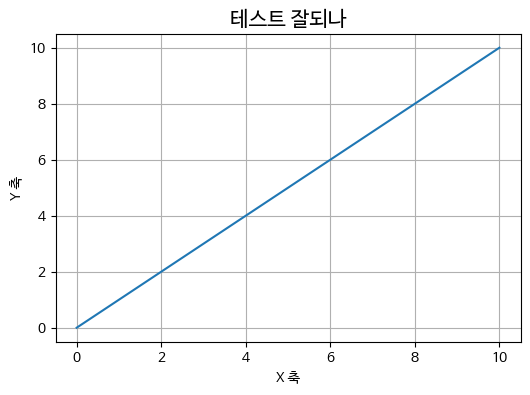

In [ ]:
# ============================================================================
# 한글 폰트 설치 및 설정
# ============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import matplotlib

# 'Noto Sans CJK KR' 폰트 설치 (Colab 환경에 따라 다를 수 있음)
# Colab에서는 apt-get으로 폰트 설치 후 폰트 캐시를 지우고 다시 로드해야 함
!sudo apt-get install -y fonts-nanum > /dev/null
!sudo fc-cache -fv > /dev/null
!rm -rf ~/.cache/matplotlib

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# 폰트 캐시 재로드
matplotlib.font_manager._load_fontmanager(try_read_cache=False)

# 한글 테스트 그래프 추가
x = np.linspace(0, 10, 100)
y = x

plt.figure(figsize=(6, 4))
plt.plot(x, y)
plt.title("테스트 잘되나", fontsize=15)
plt.xlabel("X 축"); plt.ylabel("Y 축")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats
from pathlib import Path

# ============================================================================
# 경로 설정
# ============================================================================
INPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph"
OUTPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph"


# ============================================================================
# 데이터 로드
# ============================================================================
print("=" * 80)
print("데이터 로드 중...")
print("=" * 80)
df_b = pd.read_csv(f"{INPUT_DIR}/df_b_detected.csv")
df_t = pd.read_csv(f"{INPUT_DIR}/df_t_detected.csv")

print(f"앞열(b*): {len(df_b)}행")
print(f"뒷열(t*): {len(df_t)}행")

데이터 로드 중...
앞열(b*): 11195행
뒷열(t*): 9248행


In [ ]:

# ============================================================================
# 중요 지표 14개
# ============================================================================
IMPORTANT_FEATURES = [
    'brightness_mean',
    'area_px',
    'area_cm2',
    'px_per_mm',
    'front_height_cm',
    'area_front',
    'aspect_ratio',
    'bottom_flatness',
    'core_prominence',
    'perimeter_px',
    'circularity',
    'solidity',
    'curvature',
    'roughness'
]

# 한글 라벨
FEATURE_LABELS = {
    'brightness_mean': '평균 밝기',
    'area_px': '면적 (픽셀)',
    'area_cm2': '면적 (cm²)',
    'px_per_mm': '픽셀/mm 비율',
    'front_height_cm': '정면 높이 (cm)',
    'area_front': '정면 투영 면적',
    'aspect_ratio': '장단축비',
    'bottom_flatness': '하단 평탄도',
    'core_prominence': '중심부 돌출도',
    'perimeter_px': '둘레 (픽셀)',
    'circularity': '원형도',
    'solidity': '솔리디티',
    'curvature': '곡률',
    'roughness': '거칠기'
}

# ============================================================================
# 정규분포 그래프 생성 함수
# ============================================================================
def plot_distribution(data, feature, ax, title_prefix, color):
    """단일 지표의 분포 그래프 생성"""
    # 이상치 제거 (IQR 방식)
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    filtered_data = data[(data[feature] >= lower_bound) & (data[feature] <= upper_bound)][feature]

    # 히스토그램
    n, bins, patches = ax.hist(filtered_data, bins=50, density=True,
                                alpha=0.6, color=color, edgecolor='black', linewidth=0.5)

    # 정규분포 곡선 피팅
    mu, sigma = filtered_data.mean(), filtered_data.std()
    x = np.linspace(filtered_data.min(), filtered_data.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='정규분포 곡선')

    # 평균선 및 중간값선
    ax.axvline(mu, color='red', linestyle='--', linewidth=1.5, label=f'평균: {mu:.2f}')
    ax.axvline(filtered_data.median(), color='blue', linestyle='--', linewidth=1.5,
               label=f'중간값: {filtered_data.median():.2f}')

    # 제목 및 라벨
    ax.set_title(f"{title_prefix} - {FEATURE_LABELS[feature]}", fontsize=10, fontweight='bold')
    ax.set_xlabel('값', fontsize=8)
    ax.set_ylabel('확률 밀도', fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

    # 정규성 검정 (Shapiro-Wilk test)
    if len(filtered_data) > 3:
        _, p_value = stats.shapiro(filtered_data[:5000])  # 샘플 크기 제한
        normality = "정규분포" if p_value > 0.05 else "비정규분포"
        ax.text(0.02, 0.98, f'{normality}\n(p={p_value:.4f})',
                transform=ax.transAxes, fontsize=7, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ============================================================================
# 앞열(b*) 정규분포 그래프
# ============================================================================
print("\n" + "=" * 80)
print("앞열(b*) 정규분포 그래프 생성 중...")
print("=" * 80)

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('앞열(b*) 양상추 - 14개 중요 지표 분포', fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten()

for idx, feature in enumerate(IMPORTANT_FEATURES):
    plot_distribution(df_b, feature, axes[idx], '앞열(b*)', 'skyblue')

# 마지막 빈 subplot 제거
axes[-1].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/distribution_b_front.png", dpi=300, bbox_inches='tight')
print(f"✅ 저장 완료: {OUTPUT_DIR}/distribution_b_front.png")
plt.close()

# ============================================================================
# 뒷열(t*) 정규분포 그래프
# ============================================================================
print("\n" + "=" * 80)
print("뒷열(t*) 정규분포 그래프 생성 중...")
print("=" * 80)

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('뒷열(t*) 양상추 - 14개 중요 지표 분포', fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten()

for idx, feature in enumerate(IMPORTANT_FEATURES):
    plot_distribution(df_t, feature, axes[idx], '뒷열(t*)', 'lightcoral')

# 마지막 빈 subplot 제거
axes[-1].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/distribution_t_back.png", dpi=300, bbox_inches='tight')
print(f"✅ 저장 완료: {OUTPUT_DIR}/distribution_t_back.png")
plt.close()

# ============================================================================
# 정규성 검정 결과 요약
# ============================================================================
print("\n" + "=" * 80)
print("정규성 검정 결과 요약 (Shapiro-Wilk test)")
print("=" * 80)

normality_results = []

for feature in IMPORTANT_FEATURES:
    # 앞열
    data_b = df_b[feature].dropna()
    if len(data_b) > 3:
        _, p_b = stats.shapiro(data_b[:5000])
        norm_b = "정규" if p_b > 0.05 else "비정규"
    else:
        p_b = np.nan
        norm_b = "N/A"

    # 뒷열
    data_t = df_t[feature].dropna()
    if len(data_t) > 3:
        _, p_t = stats.shapiro(data_t[:5000])
        norm_t = "정규" if p_t > 0.05 else "비정규"
    else:
        p_t = np.nan
        norm_t = "N/A"

    normality_results.append({
        '지표': FEATURE_LABELS[feature],
        '앞열_p값': p_b,
        '앞열_판정': norm_b,
        '뒷열_p값': p_t,
        '뒷열_판정': norm_t
    })

normality_df = pd.DataFrame(normality_results)
print(normality_df.to_string(index=False))

normality_df.to_csv(f"{OUTPUT_DIR}/normality_test_results.csv", index=False, encoding='utf-8-sig')
print(f"\n✅ 정규성 검정 결과 저장: {OUTPUT_DIR}/normality_test_results.csv")

print("\n" + "=" * 80)
print("Step 2 완료!")
print("=" * 80)



앞열(b*) 정규분포 그래프 생성 중...
✅ 저장 완료: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/distribution_b_front.png

뒷열(t*) 정규분포 그래프 생성 중...
✅ 저장 완료: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/distribution_t_back.png

정규성 검정 결과 요약 (Shapiro-Wilk test)
        지표        앞열_p값 앞열_판정        뒷열_p값 뒷열_판정
     평균 밝기 5.207049e-46   비정규 7.879703e-40   비정규
   면적 (픽셀) 9.409421e-45   비정규 8.368502e-64   비정규
  면적 (cm²) 1.880956e-84   비정규 1.615867e-87   비정규
  픽셀/mm 비율 3.753679e-75   비정규 6.292845e-76   비정규
정면 높이 (cm) 1.008329e-72   비정규 9.928134e-76   비정규
  정면 투영 면적 9.409421e-45   비정규 8.368502e-64   비정규
      장단축비 2.695622e-84   비정규 4.480967e-73   비정규
    하단 평탄도 1.888809e-28   비정규 7.745602e-36   비정규
   중심부 돌출도 2.064324e-93   비정규 5.345332e-92   비정규
   둘레 (픽셀) 3.317460e-51   비정규 1.931262e-52   비정규
       원형도 8.59015

#Step 3: 시계열 변화 그래프 생성
날짜를 x축으로 14개 중요 지표의 시계열 변화 시각화
bed_date_clean 기준으로 그룹화하여 평균값 계산

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ============================================================================
# 경로 설정
# ============================================================================
INPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph"
OUTPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph"

# ============================================================================
# 데이터 로드
# ============================================================================
print("=" * 80)
print("데이터 로드 중...")
print("=" * 80)
df_b = pd.read_csv(f"{INPUT_DIR}/df_b_detected.csv")
df_t = pd.read_csv(f"{INPUT_DIR}/df_t_detected.csv")

# 날짜 변환
df_b['date'] = pd.to_datetime(df_b['date'])
df_t['date'] = pd.to_datetime(df_t['date'])

print(f"앞열(b*): {len(df_b)}행")
print(f"뒷열(t*): {len(df_t)}행")

데이터 로드 중...
앞열(b*): 11195행
뒷열(t*): 9248행


In [ ]:
# ============================================================================
# bed_date_clean 기준 그룹화 및 평균 계산
# ============================================================================
print("\n" + "=" * 80)
print("bed_date_clean 기준 그룹화 및 평균 계산 중...")
print("=" * 80)

# 앞열 그룹화
df_b_grouped = df_b.groupby(['bed_date', 'date'])[IMPORTANT_FEATURES].mean().reset_index()
print(f"앞열 그룹화 결과: {len(df_b_grouped)}개 bed_date")

# 뒷열 그룹화
df_t_grouped = df_t.groupby(['bed_date', 'date'])[IMPORTANT_FEATURES].mean().reset_index()
print(f"뒷열 그룹화 결과: {len(df_t_grouped)}개 bed_date")

# ============================================================================
# 날짜별 전체 평균 계산 (모든 베드 통합)
# ============================================================================
df_b_daily = df_b.groupby('date')[IMPORTANT_FEATURES].agg(['mean', 'std', 'count']).reset_index()
df_t_daily = df_t.groupby('date')[IMPORTANT_FEATURES].agg(['mean', 'std', 'count']).reset_index()

print(f"\n앞열 날짜별 평균: {len(df_b_daily)}일")
print(f"뒷열 날짜별 평균: {len(df_t_daily)}일")


bed_date_clean 기준 그룹화 및 평균 계산 중...
앞열 그룹화 결과: 2192개 bed_date
뒷열 그룹화 결과: 2192개 bed_date

앞열 날짜별 평균: 29일
뒷열 날짜별 평균: 29일


In [ ]:
# ============================================================================
# 시계열 그래프 생성 함수
# ============================================================================
def plot_timeseries(df_daily, df_grouped, feature, ax, title_prefix, color):
    """단일 지표의 시계열 그래프 생성"""

    # 날짜별 평균 (굵은 선)
    dates = df_daily['date']
    means = df_daily[(feature, 'mean')]
    stds = df_daily[(feature, 'std')]

    # 평균선
    ax.plot(dates, means, color=color, linewidth=2.5, label='전체 평균', marker='o', markersize=4)

    # 표준편차 영역
    ax.fill_between(dates, means - stds, means + stds, alpha=0.2, color=color, label='±1 표준편차')

    # 개별 bed_date_clean 추세 (얇은 선, 투명도)
    for bed_date in df_grouped['bed_date'].unique()[:20]:  # 상위 20개만 표시
        bed_data = df_grouped[df_grouped['bed_date'] == bed_date]
        if len(bed_data) > 1:
            ax.plot(bed_data['date'], bed_data[feature],
                   color='gray', linewidth=0.5, alpha=0.3)

    # 제목 및 라벨
    ax.set_title(f"{title_prefix} - {FEATURE_LABELS[feature]}", fontsize=10, fontweight='bold')
    ax.set_xlabel('날짜', fontsize=8)
    ax.set_ylabel('값', fontsize=8)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)

    # x축 날짜 포맷
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # 통계 정보 표시
    mean_val = means.mean()
    trend = "증가" if means.iloc[-1] > means.iloc[0] else "감소"
    change_pct = ((means.iloc[-1] - means.iloc[0]) / means.iloc[0] * 100) if means.iloc[0] != 0 else 0

    ax.text(0.02, 0.98, f'평균: {mean_val:.2f}\n추세: {trend} ({change_pct:+.1f}%)',
            transform=ax.transAxes, fontsize=7, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ============================================================================
# 앞열(b*) 시계열 그래프
# ============================================================================
print("\n" + "=" * 80)
print("앞열(b*) 시계열 그래프 생성 중...")
print("=" * 80)

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.suptitle('앞열(b*) 양상추 - 14개 중요 지표 시계열 변화', fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten()

for idx, feature in enumerate(IMPORTANT_FEATURES):
    plot_timeseries(df_b_daily, df_b_grouped, feature, axes[idx], '앞열(b*)', 'steelblue')

# 마지막 빈 subplot 제거
axes[-1].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/timeseries_b_front.png", dpi=300, bbox_inches='tight')
print(f"✅ 저장 완료: {OUTPUT_DIR}/timeseries_b_front.png")
plt.close()

# ============================================================================
# 뒷열(t*) 시계열 그래프
# ============================================================================
print("\n" + "=" * 80)
print("뒷열(t*) 시계열 그래프 생성 중...")
print("=" * 80)

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.suptitle('뒷열(t*) 양상추 - 14개 중요 지표 시계열 변화', fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten()

for idx, feature in enumerate(IMPORTANT_FEATURES):
    plot_timeseries(df_t_daily, df_t_grouped, feature, axes[idx], '뒷열(t*)', 'indianred')

# 마지막 빈 subplot 제거
axes[-1].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/timeseries_t_back.png", dpi=300, bbox_inches='tight')
print(f"✅ 저장 완료: {OUTPUT_DIR}/timeseries_t_back.png")
plt.close()

# ============================================================================
# 시계열 통계 요약
# ============================================================================
print("\n" + "=" * 80)
print("시계열 통계 요약")
print("=" * 80)

timeseries_summary = []

for feature in IMPORTANT_FEATURES:
    # 앞열
    b_means = df_b_daily[(feature, 'mean')]
    b_start = b_means.iloc[0]
    b_end = b_means.iloc[-1]
    b_change_pct = ((b_end - b_start) / b_start * 100) if b_start != 0 else 0
    b_trend = "증가" if b_end > b_start else "감소"

    # 뒷열
    t_means = df_t_daily[(feature, 'mean')]
    t_start = t_means.iloc[0]
    t_end = t_means.iloc[-1]
    t_change_pct = ((t_end - t_start) / t_start * 100) if t_start != 0 else 0
    t_trend = "증가" if t_end > t_start else "감소"

    timeseries_summary.append({
        '지표': FEATURE_LABELS[feature],
        '앞열_시작': b_start,
        '앞열_종료': b_end,
        '앞열_변화율(%)': b_change_pct,
        '앞열_추세': b_trend,
        '뒷열_시작': t_start,
        '뒷열_종료': t_end,
        '뒷열_변화율(%)': t_change_pct,
        '뒷열_추세': t_trend
    })

timeseries_df = pd.DataFrame(timeseries_summary)
print(timeseries_df.to_string(index=False))

timeseries_df.to_csv(f"{OUTPUT_DIR}/timeseries_summary.csv", index=False, encoding='utf-8-sig')
print(f"\n✅ 시계열 통계 저장: {OUTPUT_DIR}/timeseries_summary.csv")

print("\n" + "=" * 80)
print("Step 3 완료!")
print("=" * 80)



앞열(b*) 시계열 그래프 생성 중...
✅ 저장 완료: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/timeseries_b_front.png

뒷열(t*) 시계열 그래프 생성 중...
✅ 저장 완료: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/timeseries_t_back.png

시계열 통계 요약
        지표        앞열_시작        앞열_종료  앞열_변화율(%) 앞열_추세        뒷열_시작        뒷열_종료  뒷열_변화율(%) 뒷열_추세
     평균 밝기    94.661598    99.526285   5.139028    증가   119.922658   103.228531 -13.920744    감소
   면적 (픽셀) 53839.283951 71458.766026  32.726071    증가 40838.986523 41396.092466   1.364152    증가
  면적 (cm²)  1234.007622   886.480530 -28.162475    감소   971.563866   514.197684 -47.075257    감소
  픽셀/mm 비율     0.898694     0.898692  -0.000258    감소     0.898392     0.898684   0.032546    증가
정면 높이 (cm)    44.248336    40.139303  -9.286300    감소    35.806295    26.444302 -26.146219    감소
  정면

#Step 4: 상위 10개 베드 선정
평균 및 중간값 기준으로 우수 베드 선정

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================================
# 경로 설정
# ============================================================================
INPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph"
OUTPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph"

# ============================================================================
# 데이터 로드
# ============================================================================
print("=" * 80)
print("데이터 로드 중...")
print("=" * 80)
df_b = pd.read_csv(f"{INPUT_DIR}/df_b_detected.csv")
df_t = pd.read_csv(f"{INPUT_DIR}/df_t_detected.csv")

print(f"앞열(b*): {len(df_b)}행")
print(f"뒷열(t*): {len(df_t)}행")

데이터 로드 중...
앞열(b*): 11195행
뒷열(t*): 9248행


In [ ]:
# ============================================================================
# 중요 지표 14개
# ============================================================================
# 생육 우수 판단 기준 (값이 클수록 좋은 지표)
POSITIVE_FEATURES = [
    'area_cm2',           # 면적 클수록 좋음
    'front_height_cm',    # 높이 클수록 좋음
    'solidity',           # 밀집도 높을수록 좋음
    'circularity',        # 원형도 높을수록 좋음 (결구)
    'bottom_flatness'     # 평탄도 높을수록 좋음
]

# ============================================================================
# bed_date 기준 그룹화 및 통계 계산
# ============================================================================
print("\n" + "=" * 80)
print("bed 기준 그룹화 및 통계 계산 중...")
print("=" * 80)

def calculate_bed_stats(df, group_name):
    """베드별 통계 계산"""

    # bed 기준 그룹화
    grouped = df.groupby('bed')[IMPORTANT_FEATURES].agg(['mean', 'median', 'std', 'count']).reset_index()

    # 컬럼명 단순화
    grouped.columns = ['bed'] + [f"{feat}_{stat}" for feat in IMPORTANT_FEATURES for stat in ['mean', 'median', 'std', 'count']]

    # 샘플 수 필터링 (최소 2개 이상)
    grouped = grouped[grouped['brightness_mean_count'] >= 2].copy()

    print(f"\n{group_name} 통계:")
    print(f"  - 총 bed_date 수: {len(grouped)}개")
    print(f"  - 평균 샘플 수: {grouped['brightness_mean_count'].mean():.1f}개")

    return grouped

# 앞열 통계
df_b_stats = calculate_bed_stats(df_b, "앞열(b*)")

# 뒷열 통계
df_t_stats = calculate_bed_stats(df_t, "뒷열(t*)")

# ============================================================================
# 종합 점수 계산 (생육 우수도)
# ============================================================================
print("\n" + "=" * 80)
print("종합 점수 계산 중...")
print("=" * 80)

def calculate_composite_score(df_stats, features):
    """종합 점수 계산 (Z-score 정규화 후 합산)"""

    scores = pd.DataFrame()
    scores['bed'] = df_stats['bed']

    # 평균 기준 Z-score
    mean_scores = []
    for feat in features:
        col = f"{feat}_mean"
        if col in df_stats.columns:
            z_score = (df_stats[col] - df_stats[col].mean()) / df_stats[col].std()
            mean_scores.append(z_score)

    scores['mean_score'] = pd.concat(mean_scores, axis=1).mean(axis=1)

    # 중간값 기준 Z-score
    median_scores = []
    for feat in features:
        col = f"{feat}_median"
        if col in df_stats.columns:
            z_score = (df_stats[col] - df_stats[col].mean()) / df_stats[col].std()
            median_scores.append(z_score)

    scores['median_score'] = pd.concat(median_scores, axis=1).mean(axis=1)

    # 종합 점수 (평균과 중간값의 평균)
    scores['composite_score'] = (scores['mean_score'] + scores['median_score']) / 2

    # 원본 데이터 병합
    scores = scores.merge(df_stats, on='bed')

    return scores

# 앞열 점수 계산
df_b_scores = calculate_composite_score(df_b_stats, POSITIVE_FEATURES)
print(f"앞열 점수 계산 완료: {len(df_b_scores)}개 베드")

# 뒷열 점수 계산
df_t_scores = calculate_composite_score(df_t_stats, POSITIVE_FEATURES)
print(f"뒷열 점수 계산 완료: {len(df_t_scores)}개 베드")

# ============================================================================
# 상위 10개 베드 선정
# ============================================================================
print("\n" + "=" * 80)
print("상위 10개 베드 선정 (종합 점수 기준)")
print("=" * 80)

# 앞열 상위 10개
top10_b = df_b_scores.nlargest(10, 'composite_score')
print("\n[앞열(b*) 상위 10개 베드]")
print(top10_b[['bed', 'composite_score', 'area_cm2_mean', 'front_height_cm_mean',
              'circularity_mean', 'solidity_mean', 'brightness_mean_count']].to_string(index=False))

# 뒷열 상위 10개
top10_t = df_t_scores.nlargest(10, 'composite_score')
print("\n[뒷열(t*) 상위 10개 베드]")
print(top10_t[['bed', 'composite_score', 'area_cm2_mean', 'front_height_cm_mean',
              'circularity_mean', 'solidity_mean', 'brightness_mean_count']].to_string(index=False))

# ============================================================================
# 하위 10개 베드 선정 (비교용)
# ============================================================================
print("\n" + "=" * 80)
print("하위 10개 베드 선정 (종합 점수 기준)")
print("=" * 80)

# 앞열 하위 10개
bottom10_b = df_b_scores.nsmallest(10, 'composite_score')
print("\n[앞열(b*) 하위 10개 베드]")
print(bottom10_b[['bed', 'composite_score', 'area_cm2_mean', 'front_height_cm_mean',
                 'circularity_mean', 'solidity_mean', 'brightness_mean_count']].to_string(index=False))

# 뒷열 하위 10개
bottom10_t = df_t_scores.nsmallest(10, 'composite_score')
print("\n[뒷열(t*) 하위 10개 베드]")
print(bottom10_t[['bed', 'composite_score', 'area_cm2_mean', 'front_height_cm_mean',
                 'circularity_mean', 'solidity_mean', 'brightness_mean_count']].to_string(index=False))


# ============================================================================
# 상위 vs 하위 비교 통계
# ============================================================================
print("\n" + "=" * 80)
print("상위 vs 하위 베드 비교 통계")
print("=" * 80)

comparison_stats = []

for feat in POSITIVE_FEATURES:
    mean_col = f"{feat}_mean"

    # 앞열
    b_top_mean = top10_b[mean_col].mean()
    b_bottom_mean = bottom10_b[mean_col].mean()
    b_diff_pct = ((b_top_mean - b_bottom_mean) / b_bottom_mean * 100) if b_bottom_mean != 0 else 0

    # 뒷열
    t_top_mean = top10_t[mean_col].mean()
    t_bottom_mean = bottom10_t[mean_col].mean()
    t_diff_pct = ((t_top_mean - t_bottom_mean) / t_bottom_mean * 100) if t_bottom_mean != 0 else 0

    comparison_stats.append({
        '지표': feat,
        '앞열_상위평균': b_top_mean,
        '앞열_하위평균': b_bottom_mean,
        '앞열_차이(%)': b_diff_pct,
        '뒷열_상위평균': t_top_mean,
        '뒷열_하위평균': t_bottom_mean,
        '뒷열_차이(%)': t_diff_pct
    })

comparison_df = pd.DataFrame(comparison_stats)
print(comparison_df.to_string(index=False))

comparison_df.to_csv(f"{OUTPUT_DIR}/top_vs_bottom_comparison.csv", index=False, encoding='utf-8-sig')
print(f"\n✅ 비교 통계 저장: {OUTPUT_DIR}/top_vs_bottom_comparison.csv")

print("\n" + "=" * 80)
print("Step 4 완료!")
print("=" * 80)



bed 기준 그룹화 및 통계 계산 중...

앞열(b*) 통계:
  - 총 bed_date 수: 96개
  - 평균 샘플 수: 116.6개

뒷열(t*) 통계:
  - 총 bed_date 수: 96개
  - 평균 샘플 수: 96.3개

종합 점수 계산 중...
앞열 점수 계산 완료: 96개 베드
뒷열 점수 계산 완료: 96개 베드

상위 10개 베드 선정 (종합 점수 기준)

[앞열(b*) 상위 10개 베드]
  bed  composite_score  area_cm2_mean  front_height_cm_mean  circularity_mean  solidity_mean  brightness_mean_count
bed63         1.209862     887.835770             41.355040          0.462228       0.888433                    104
bed28         1.175687     995.102486             40.904041          0.452593       0.878456                    140
bed26         1.019886    1154.405359             44.516306          0.451572       0.874130                    102
bed93         0.989690     813.370450             40.089895          0.500820       0.895940                    141
bed05         0.923202     886.943963             39.530708          0.458675       0.880712                    142
bed25         0.859405    1261.520863             43.408540          0.4

# 시계열 데이터 이상 이유

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ============================================================================
# Configuration
# ============================================================================
INPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph"
OUTPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph"

# ============================================================================
# Load Data
# ============================================================================
print("=" * 80)
print("INVESTIGATION: Time Series Stagnation Issue")
print("=" * 80)

df_b = pd.read_csv(f"{INPUT_DIR}/df_b_detected.csv")
df_t = pd.read_csv(f"{INPUT_DIR}/df_t_detected.csv")

df_b['date'] = pd.to_datetime(df_b['date'])
df_t['date'] = pd.to_datetime(df_t['date'])

print(f"\nFront row (b*): {len(df_b)} samples")
print(f"Back row (t*): {len(df_t)} samples")

INVESTIGATION: Time Series Stagnation Issue

Front row (b*): 11195 samples
Back row (t*): 9248 samples


In [ ]:
# ============================================================================
# INVESTIGATION 1: Daily Sample Composition
# ============================================================================
print("\n" + "=" * 80)
print("INVESTIGATION 1: Daily Sample Composition")
print("=" * 80)

def analyze_daily_composition(df, group_name):
    """Analyze which beds are sampled each day"""

    daily_stats = []

    for date in sorted(df['date'].unique()):
        day_data = df[df['date'] == date]

        # Extract bed number
        day_data['bed_num'] = day_data['bed_date'].str.extract(r'(bed\d+)')[0]

        unique_beds = day_data['bed_num'].nunique()
        total_samples = len(day_data)
        avg_area = day_data['area_cm2'].mean()
        std_area = day_data['area_cm2'].std()

        # Check for outliers (3 sigma rule)
        Q1 = day_data['area_cm2'].quantile(0.25)
        Q3 = day_data['area_cm2'].quantile(0.75)
        IQR = Q3 - Q1
        outliers = len(day_data[(day_data['area_cm2'] < Q1 - 3*IQR) |
                                 (day_data['area_cm2'] > Q3 + 3*IQR)])

        daily_stats.append({
            'date': date,
            'unique_beds': unique_beds,
            'total_samples': total_samples,
            'avg_area_cm2': avg_area,
            'std_area_cm2': std_area,
            'cv_area': (std_area / avg_area * 100) if avg_area > 0 else 0,
            'outliers': outliers,
            'outlier_ratio': (outliers / total_samples * 100) if total_samples > 0 else 0
        })

    daily_df = pd.DataFrame(daily_stats)

    print(f"\n{group_name} Daily Composition:")
    print(daily_df.to_string(index=False))

    return daily_df

daily_b = analyze_daily_composition(df_b, "Front row (b*)")
daily_t = analyze_daily_composition(df_t, "Back row (t*)")

# Save daily composition
daily_b.to_csv(f"{OUTPUT_DIR}/daily_composition_b.csv", index=False, encoding='utf-8-sig')
daily_t.to_csv(f"{OUTPUT_DIR}/daily_composition_t.csv", index=False, encoding='utf-8-sig')



INVESTIGATION 1: Daily Sample Composition

Front row (b*) Daily Composition:
      date  unique_beds  total_samples  avg_area_cm2  std_area_cm2    cv_area  outliers  outlier_ratio
2025-11-28           84            486   1234.007622   1818.039588 147.328068        68      13.991770
2025-11-29           66            369    899.636307   1394.685569 155.027710        17       4.607046
2025-11-30           95            510    699.188716    196.009637  28.033867        20       3.921569
2025-12-01           71            385    711.425383    179.861320  25.281825        10       2.597403
2025-12-02           86            460    695.603313    174.094663  25.027866        14       3.043478
2025-12-03           87            449    768.902807    213.469886  27.762922        21       4.677060
2025-12-04           93            442    788.006384    266.191175  33.780332         4       0.904977
2025-12-05           94            433    757.734941    267.670466  35.325079         3       0.69

/tmp/ipython-input-1351429231.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_data['bed_num'] = day_data['bed_date'].str.extract(r'(bed\d+)')[0]
/tmp/ipython-input-1351429231.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_data['bed_num'] = day_data['bed_date'].str.extract(r'(bed\d+)')[0]
/tmp/ipython-input-1351429231.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in


Back row (t*) Daily Composition:
      date  unique_beds  total_samples  avg_area_cm2  std_area_cm2    cv_area  outliers  outlier_ratio
2025-11-28           84            371    971.563866   1502.577309 154.655537        58      15.633423
2025-11-29           66            262    700.540485   1516.247707 216.439698        11       4.198473
2025-11-30           95            344    499.284752    181.431340  36.338250         0       0.000000
2025-12-01           71            244    484.058874    172.623038  35.661579         0       0.000000
2025-12-02           86            307    477.128189    152.797131  32.024335         0       0.000000
2025-12-03           87            339    504.963196    164.036559  32.484855         0       0.000000
2025-12-04           93            380    536.494807    162.553487  30.299173         6       1.578947
2025-12-05           94            352    481.528973    144.809897  30.072935         0       0.000000
2025-12-06           89            342 

/tmp/ipython-input-1351429231.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_data['bed_num'] = day_data['bed_date'].str.extract(r'(bed\d+)')[0]
/tmp/ipython-input-1351429231.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_data['bed_num'] = day_data['bed_date'].str.extract(r'(bed\d+)')[0]
/tmp/ipython-input-1351429231.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

In [ ]:

# ============================================================================
# INVESTIGATION 5: Individual Bed Tracking
# ============================================================================
print("\n" + "=" * 80)
print("INVESTIGATION 5: Individual Bed Tracking (Sample)")
print("=" * 80)

def track_individual_beds(df, group_name, top_n=5):
    """Track individual beds over time"""

    df['bed_num'] = df['bed_date'].str.extract(r'(bed\d+)')[0]

    # Select beds that appear most frequently
    bed_counts = df.groupby('bed_num')['date'].nunique()
    top_beds = bed_counts.nlargest(top_n).index.tolist()

    print(f"\n{group_name} Individual Bed Tracking (Top {top_n} beds):")

    for bed in top_beds:
        bed_data = df[df['bed_num'] == bed].sort_values('date')

        if len(bed_data) > 1:
            start_area = bed_data['area_cm2'].iloc[0]
            end_area = bed_data['area_cm2'].iloc[-1]
            change = end_area - start_area
            change_pct = (change / start_area * 100) if start_area > 0 else 0

            print(f"\n{bed}: {len(bed_data)} measurements")
            print(f"  Start: {start_area:.2f} cm² → End: {end_area:.2f} cm²")
            print(f"  Change: {change:+.2f} cm² ({change_pct:+.1f}%)")
            print(f"  Date range: {bed_data['date'].min().strftime('%Y-%m-%d')} to {bed_data['date'].max().strftime('%Y-%m-%d')}")

track_individual_beds(df_b, "Front row (b*)")
track_individual_beds(df_t, "Back row (t*)")



INVESTIGATION 5: Individual Bed Tracking (Sample)

Front row (b*) Individual Bed Tracking (Top 5 beds):

bed01: 138 measurements
  Start: 584.11 cm² → End: 63.68 cm²
  Change: -520.43 cm² (-89.1%)
  Date range: 2025-11-28 to 2025-12-26

bed02: 146 measurements
  Start: 468.98 cm² → End: 301.38 cm²
  Change: -167.59 cm² (-35.7%)
  Date range: 2025-11-28 to 2025-12-26

bed12: 138 measurements
  Start: 630.53 cm² → End: 90.56 cm²
  Change: -539.97 cm² (-85.6%)
  Date range: 2025-11-28 to 2025-12-26

bed35: 134 measurements
  Start: 513.23 cm² → End: 18.61 cm²
  Change: -494.62 cm² (-96.4%)
  Date range: 2025-11-28 to 2025-12-26

bed38: 133 measurements
  Start: 647.90 cm² → End: 795.48 cm²
  Change: +147.59 cm² (+22.8%)
  Date range: 2025-11-28 to 2025-12-26

Back row (t*) Individual Bed Tracking (Top 5 beds):

bed01: 115 measurements
  Start: 332.93 cm² → End: 443.35 cm²
  Change: +110.42 cm² (+33.2%)
  Date range: 2025-11-28 to 2025-12-26

bed02: 119 measurements
  Start: 391.35 cm² → 

#평균값 산출하기1: all bed데이터에 대하여

In [ ]:
import pandas as pd
import re
import numpy as np
from pathlib import Path

# =========================================================
# 베드-날짜(bed_date) 기준 통계 산출 (다변수 + CV 포함)
# - groupby: bed_date
# - 대상 변수: area_cm2, conf, brightness_mean, blur_score,
#            perimeter_px, circularity, solidity, concavity, curvature, roughness
# - 통계: mean, std, min, max, cv(std/mean)
# - 결과: 컬럼을 모두 펼쳐서(변수_통계) 엑셀로 저장
# =========================================================

# ====== 0) 입력/출력 경로 ======
# (1) 사용자가 준 엑셀(원본 시트) 기준으로 진행
in_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/features_all_lettuce.xlsx"
sheet_name = "Sheet1"

out_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/260201_lettuce index_statical.xlsx"

# 출력 디렉토리 생성
Path(out_path).parent.mkdir(parents=True, exist_ok=True)

# 선택: cam 필터(필요 없으면 None)
CAM_FILTER = "cam2"   # 예: "cam0" 또는 None

# ====== 1) 로드 ======
df = pd.read_excel(in_path, sheet_name=sheet_name)

# ====== 2) base_key에서 bed/date/cam 파싱 ======
# base_key 예시: bed00_20251205_094145_cam2

def clean_base_key_for_bed_date(base_key_str):
    """bed00_20251204_093629_cam2 -> bed00_20251204"""
    try:
        parts = str(base_key_str).split('_')
        if len(parts) >= 2:
            return f"{parts[0]}_{parts[1]}"
    except:
        pass
    return np.nan

def extract_bed_num(bed_date_str):
    """bed00_20251204 -> 00"""
    try:
        return int(str(bed_date_str).split('_')[0][3:])
    except:
        return np.nan

def extract_date_str(bed_date_str):
    """bed00_20251204 -> 20251204"""
    try:
        return str(bed_date_str).split('_')[1]
    except:
        return np.nan

def extract_cam(base_key_str):
    """bed00_20251205_094145_cam2 -> cam2"""
    try:
        parts = str(base_key_str).split('_')
        if len(parts) >= 4:
            return parts[3]
    except:
        pass
    return np.nan

df['bed_date'] = df['base_key'].apply(clean_base_key_for_bed_date)
df['bed'] = df['bed_date'].apply(extract_bed_num)
df['date'] = df['bed_date'].apply(extract_date_str)
df['cam'] = df['base_key'].apply(extract_cam)

# 파싱 실패 확인
bad = df[df["bed"].isna() | df["date"].isna() | df["cam"].isna()]
if len(bad) > 0:
    print(f"[경고] 파일명 파싱 실패 행: {len(bad)}개 (패턴 불일치 가능)")

# 선택: cam 필터
if CAM_FILTER is not None:
    df = df[df["cam"].str.lower() == str(CAM_FILTER).lower()].copy()

# ====== 3) 집계 대상 컬럼 ======
IMPORTANT_FEATURES = [
    'brightness_mean',
    'area_px',
    'area_cm2',
    'px_per_mm',
    'front_height_cm',
    'area_front',
    'aspect_ratio',
    'bottom_flatness',
    'core_prominence',
    'perimeter_px',
    'circularity',
    'solidity',
    'curvature',
    'roughness'
]

metrics = IMPORTANT_FEATURES

missing = [c for c in metrics if c not in df.columns]
if missing:
    raise ValueError(f"다음 컬럼이 엑셀에 없습니다: {missing}")

# 숫자 변환(문자 들어있으면 NaN 될 수 있음)
for c in metrics:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ====== 3.1) 필터링: 0값 제외 및 area_cm2 < 10 제외 ======
print("\n" + "=" * 80)
print("통계 산출 전 데이터 필터링 중...")
print("  - 모든 중요 지표에서 0 값 제외")
print("  - 'area_cm2'에서 10 미만 값 제외")
print("=" * 80)

df_filtered_for_stats = df.copy() # 원본 데이터프레임을 유지하기 위해 복사본 사용

initial_rows = len(df_filtered_for_stats)

for metric in metrics:
    # 0값 제외 (NaN으로 처리하여 통계 계산 시 자동 제외되도록 함)
    df_filtered_for_stats.loc[df_filtered_for_stats[metric] == 0, metric] = np.nan

# area_cm2에 대한 추가 필터링 (10 미만 값 제외)
if 'area_cm2' in metrics:
    df_filtered_for_stats.loc[df_filtered_for_stats['area_cm2'] < 10, 'area_cm2'] = np.nan

# 모든 metric 컬럼에 대해 NaN이 아닌 값을 가진 행만 유지
df_filtered_for_stats = df_filtered_for_stats.dropna(subset=metrics)

final_rows = len(df_filtered_for_stats)
print(f"필터링 후 데이터 (모든 지표가 NaN이 아닌 행 기준): {final_rows}행 (원본 {initial_rows}행)")


# ====== 4) bed_date로 그룹 묶어서 통계 산출 ======
g = df_filtered_for_stats.groupby("bed_date", dropna=False)[metrics]

# 기본 통계
base = g.agg(["mean", "std", "min", "max"])  # MultiIndex columns

# CV = std/mean (mean이 0이면 NaN)
means = g.mean()
stds = g.std()
cv = stds.divide(means.replace({0: np.nan}))
cv.columns = pd.MultiIndex.from_product([cv.columns, ["cv"]])

# 합치기
agg = pd.concat([base, cv], axis=1)

# 컬럼 펼치기: (metric, stat) -> metric_stat
agg.columns = [f"{m}_{s}" for (m, s) in agg.columns]

# 부가정보: bed/date 분리(정렬용)
# bed_date = bed00_YYYYMMDD
agg = agg.reset_index()
# bed 컬럼이 NaN이 아닌 값만 정수형으로 변환. NaN은 pandas Int64Dtype으로 유지
agg["bed"] = agg["bed_date"].apply(extract_bed_num) # Re-extract bed number, it will be float for NaN
agg['bed'] = agg['bed'].astype('Int64') # Use nullable integer dtype
agg["date"] = agg["bed_date"].apply(extract_date_str)

# 정렬
agg = agg.sort_values(["bed", "date"]).reset_index(drop=True)

# ====== 5) 저장 (엑셀) ======
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    # 통계표
    agg.to_excel(writer, index=False, sheet_name="bed_date_stats")

    # 원본 일부(검증용) - 필요 없으면 주석
    df[["base_key", "bed_date"] + metrics].to_excel(writer, index=False, sheet_name="sample_rows")

print("완료!")
print("입력:", in_path)
print("출력:", out_path)
print("rows:", len(df), " / groups:", agg.shape[0])
agg.head(20)


통계 산출 전 데이터 필터링 중...
  - 모든 중요 지표에서 0 값 제외
  - 'area_cm2'에서 10 미만 값 제외
필터링 후 데이터 (모든 지표가 NaN이 아닌 행 기준): 20435행 (원본 20443행)
완료!
입력: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/features_all_lettuce.xlsx
출력: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/260201_lettuce index_statical.xlsx
rows: 20443  / groups: 2192


,bed_date,brightness_mean_mean,brightness_mean_std,brightness_mean_min,brightness_mean_max,area_px_mean,area_px_std,area_px_min,area_px_max,area_cm2_mean,...,aspect_ratio_cv,bottom_flatness_cv,core_prominence_cv,perimeter_px_cv,circularity_cv,solidity_cv,curvature_cv,roughness_cv,bed,date
0,bed00_20251204,107.594352,27.694761,75.422150,145.731896,36700.000000,29251.873555,6214.0,70963.0,520.567351,...,0.444148,0.375186,0.013479,0.461039,0.255578,0.106264,0.499023,0.374510,0,20251204
1,bed00_20251205,100.027869,18.567569,67.594290,123.196661,65880.400000,20598.706945,39828.0,94459.0,841.929123,...,0.237241,0.366570,0.001939,0.118352,0.224331,0.086167,0.210969,0.133807,0,20251205
2,bed00_20251206,113.435173,25.745565,75.606485,148.275219,45325.666667,19954.151548,4506.0,72953.0,549.729141,...,0.285288,0.415614,0.001448,0.299842,0.206669,0.034563,0.258784,0.224463,0,20251206
3,bed00_20251207,109.592063,27.304253,64.433292,140.503711,54269.000000,20603.771106,31391.0,100438.0,726.107080,...,0.217511,0.296387,0.000929,0.217408,0.168460,0.040148,0.132167,0.095722,0,20251207
4,bed00_20251208,119.168258,25.683999,92.888289,157.679478,50594.125000,17838.824508,30675.0,76662.0,664.377840,...,0.281927,0.372077,0.002790,0.161916,0.142261,0.036803,0.259654,0.182698,0,20251208
5,bed00_20251209,98.767326,18.693665,67.672649,122.765800,64087.555556,9470.742198,48600.0,75610.0,803.787441,...,0.199828,0.351573,0.000990,0.093932,0.175186,0.058765,0.235672,0.160439,0,20251209
6,bed00_20251210,140.125727,37.565784,72.455837,187.246973,22786.111111,23438.526929,2065.0,63786.0,289.965326,...,0.576551,0.345283,0.005331,0.712778,0.158579,0.058176,0.354905,0.264627,0,20251210
7,bed00_20251211,136.299889,26.431261,93.131713,166.975703,27905.444444,26094.117901,2485.0,69272.0,366.378967,...,0.788210,0.402076,0.008758,0.568820,0.217633,0.096087,0.317922,0.239643,0,20251211
8,bed00_20251212,134.715954,19.460640,103.511637,164.499137,14788.090909,13947.210993,2664.0,37004.0,207.662738,...,0.461199,0.447870,0.003879,0.475010,0.338804,0.150425,0.259268,0.232444,0,20251212
9,bed00_20251213,114.338133,38.303710,66.874637,177.675045,59492.000000,36036.999104,2228.0,124997.0,764.456062,...,1.400353,0.418191,0.059848,0.372383,0.208369,0.062231,0.331174,0.171793,0,20251213


#평균값 산출하기 2: 평균+표준편차에 대하여

In [ ]:
import pandas as pd
import re
import numpy as np
from pathlib import Path

# ====== 0) 입력/출력 경로 ======
# (1) 사용자가 준 엑셀(원본 시트) 기준으로 진행
in_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/features_all_lettuce.xlsx"
sheet_name = "Sheet1"

out_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/260201_lettuce_index_statical_improved.xlsx"

# 출력 디렉토리 생성
Path(out_path).parent.mkdir(parents=True, exist_ok=True)

# 선택: cam 필터(필요 없으면 None)
CAM_FILTER = "cam2"   # 예: "cam0" 또는 None

# ====== 1) 로드 ======
df = pd.read_excel(in_path, sheet_name=sheet_name)

# ====== 2) base_key에서 bed/date/cam 파싱 ======
# base_key 예시: bed00_20251205_094145_cam2

def clean_base_key_for_bed_date(base_key_str):
    """bed00_20251204_093629_cam2 -> bed00_20251204"""
    try:
        parts = str(base_key_str).split('_')
        if len(parts) >= 2:
            return f"{parts[0]}_{parts[1]}"
    except:
        pass
    return np.nan

def extract_bed_num(bed_date_str):
    """bed00_20251204 -> 00"""
    try:
        return int(str(bed_date_str).split('_')[0][3:])
    except:
        return np.nan

def extract_date_str(bed_date_str):
    """bed00_20251204 -> 20251204"""
    try:
        return str(bed_date_str).split('_')[1]
    except:
        return np.nan

def extract_cam(base_key_str):
    """bed00_20251205_094145_cam2 -> cam2"""
    try:
        parts = str(base_key_str).split('_')
        if len(parts) >= 4:
            return parts[3]
    except:
        pass
    return np.nan

df['bed_date'] = df['base_key'].apply(clean_base_key_for_bed_date)
df['bed'] = df['bed_date'].apply(extract_bed_num)
df['date'] = df['bed_date'].apply(extract_date_str)
df['cam'] = df['base_key'].apply(extract_cam)

# 파싱 실패 확인
bad = df[df["bed"].isna() | df["date"].isna() | df["cam"].isna()]
if len(bad) > 0:
    print(f"[경고] 파일명 파싱 실패 행: {len(bad)}개 (패턴 불일치 가능)")

# 선택: cam 필터
if CAM_FILTER is not None:
    df = df[df["cam"].str.lower() == str(CAM_FILTER).lower()].copy()

# ====== 3) 집계 대상 컬럼 ======
IMPORTANT_FEATURES = [
    'brightness_mean',
    'area_px',
    'area_cm2',
    'px_per_mm',
    'front_height_cm',
    'area_front',
    'aspect_ratio',
    'bottom_flatness',
    'core_prominence',
    'perimeter_px',
    'circularity',
    'solidity',
    'curvature',
    'roughness'
]

metrics = IMPORTANT_FEATURES

missing = [c for c in metrics if c not in df.columns]
if missing:
    raise ValueError(f"다음 컬럼이 엑셀에 없습니다: {missing}")

# 숫자 변환(문자 들어있으면 NaN 될 수 있음)
for c in metrics:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ====== 3.1) 필터링: 0값 제외 및 area_cm2 < 10 제외 ======
print("\n" + "=" * 80)
print("통계 산출 전 데이터 필터링 중...")
print("  - 모든 중요 지표에서 0 값 제외")
print("  - 'area_cm2'에서 10 미만 값 제외")
print("=" * 80)

df_filtered_for_stats = df.copy() # 원본 데이터프레임을 유지하기 위해 복사본 사용

initial_rows = len(df_filtered_for_stats)

for metric in metrics:
    # 0값 제외 (NaN으로 처리하여 통계 계산 시 자동 제외되도록 함)
    df_filtered_for_stats.loc[df_filtered_for_stats[metric] == 0, metric] = np.nan

# area_cm2에 대한 추가 필터링 (10 미만 값 제외)
if 'area_cm2' in metrics:
    df_filtered_for_stats.loc[df_filtered_for_stats['area_cm2'] < 10, 'area_cm2'] = np.nan

# 모든 metric 컬럼에 대해 NaN이 아닌 값을 가진 행만 유지
df_filtered_for_stats = df_filtered_for_stats.dropna(subset=metrics)

final_rows = len(df_filtered_for_stats)
print(f"필터링 후 데이터 (모든 지표가 NaN이 아닌 행 기준): {final_rows}행 (원본 {initial_rows}행)")


# ====== 4) bed_date로 그룹 묶어서 다중 통계 산출 ======
print("\n" + "=" * 80)
print("다중 통계량 계산 중...")
print("  - mean: 전체 평균")
print("  - median: 중간값 (이상치에 강건)")
print("  - top50_mean: 상위 50% 평균 (큰 개체 중심)")
print("  - q75: 75 백분위수")
print("  - max: 최대값")
print("  - std: 표준편차")
print("  - min: 최소값")
print("  - cv: 변동계수 (std/mean)")
print("=" * 80)

g = df_filtered_for_stats.groupby("bed_date", dropna=False)[metrics]

# 커스텀 통계 함수 정의
def top50_mean(x):
    """상위 50% 값의 평균"""
    if len(x) == 0:
        return np.nan
    n_top = max(1, int(len(x) * 0.5))  # 최소 1개는 선택
    return x.nlargest(n_top).mean()

def q75(x):
    """75 백분위수"""
    return x.quantile(0.75)

# 다중 통계량 계산
agg_dict = {
    metric: [
        ('mean', 'mean'),           # 전체 평균
        ('median', 'median'),       # 중간값
        ('top50_mean', top50_mean), # 상위 50% 평균
        ('q75', q75),               # 75 백분위수
        ('max', 'max'),             # 최대값
        ('std', 'std'),             # 표준편차
        ('min', 'min')              # 최소값
    ]
    for metric in metrics
}

# agg 실행
agg = g.agg(agg_dict)

# CV 계산 (std/mean)
means = g.mean()
stds = g.std()
cv = stds.divide(means.replace({0: np.nan}))

# CV를 MultiIndex로 변환하여 agg에 추가
cv_multi = pd.DataFrame(cv.values, index=cv.index, columns=pd.MultiIndex.from_product([cv.columns, ['cv']]))

# 기존 agg와 cv_multi 병합
agg = pd.concat([agg, cv_multi], axis=1)

# 컬럼 펼치기: (metric, stat) -> metric_stat
agg.columns = [f"{m}_{s}" for (m, s) in agg.columns]

# 부가정보: bed/date 분리(정렬용)
agg = agg.reset_index()
agg["bed"] = agg["bed_date"].apply(extract_bed_num)
agg['bed'] = agg['bed'].astype('Int64')
agg["date"] = agg["bed_date"].apply(extract_date_str)

# 정렬
agg = agg.sort_values(["bed", "date"]).reset_index(drop=True)

# ====== 5) 저장 (엑셀) ======
print("\n" + "=" * 80)
print("엑셀 파일 저장 중...")
print("=" * 80)

with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    # 통계표
    agg.to_excel(writer, index=False, sheet_name="bed_date_stats")

    # 원본 일부(검증용) - 필요 없으면 주석
    df[["base_key", "bed_date"] + metrics].to_excel(writer, index=False, sheet_name="sample_rows")

print("\n완료!")
print("입력:", in_path)
print("출력:", out_path)
print("rows:", len(df), " / groups:", agg.shape[0])
print("\n상위 20개 행:")
print(agg.head(20))

# ====== 6) 통계량 비교 요약 ======
print("\n" + "=" * 80)
print("통계량 비교 요약 (area_front 기준)")
print("=" * 80)

if 'area_front_mean' in agg.columns:
    comparison = agg[['bed_date', 'bed', 'date',
                      'area_front_mean', 'area_front_median',
                      'area_front_top50_mean', 'area_front_q75',
                      'area_front_max']].copy()

    print("\n상위 10개 bed_date의 area_front 통계량 비교:")
    print(comparison.head(10).to_string(index=False))

    # 통계량 간 차이 계산
    comparison['diff_mean_median'] = comparison['area_front_mean'] - comparison['area_front_median']
    comparison['diff_mean_top50'] = comparison['area_front_mean'] - comparison['area_front_top50_mean']

    print("\n통계량 차이 요약:")
    print(f"mean vs median 평균 차이: {comparison['diff_mean_median'].mean():.2f} px")
    print(f"mean vs top50_mean 평균 차이: {comparison['diff_mean_top50'].mean():.2f} px")
    print(f"top50_mean이 mean보다 큰 경우: {(comparison['diff_mean_top50'] < 0).sum()} / {len(comparison)} ({(comparison['diff_mean_top50'] < 0).sum() / len(comparison) * 100:.1f}%)")



통계 산출 전 데이터 필터링 중...
  - 모든 중요 지표에서 0 값 제외
  - 'area_cm2'에서 10 미만 값 제외
필터링 후 데이터 (모든 지표가 NaN이 아닌 행 기준): 20435행 (원본 20443행)

다중 통계량 계산 중...
  - mean: 전체 평균
  - median: 중간값 (이상치에 강건)
  - top50_mean: 상위 50% 평균 (큰 개체 중심)
  - q75: 75 백분위수
  - max: 최대값
  - std: 표준편차
  - min: 최소값
  - cv: 변동계수 (std/mean)

엑셀 파일 저장 중...

완료!
입력: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/features_all_lettuce.xlsx
출력: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/260201_lettuce_index_statical_improved.xlsx
rows: 20443  / groups: 2192

상위 20개 행:
          bed_date  brightness_mean_mean  brightness_mean_median  \
0   bed00_20251204            107.594352              108.823471   
1   bed00_20251205            100.027869               94.851373   
2   bed00_20251206            113.435173              114.848974   
3   bed00_20251207            109.592063              107.352898   
4   bed00_20251208            11

#6. 상위 10개 베드만 날짜별로 모니터링하기

Loading data from Excel...

Total records: 2192
Date range: 2025-11-28 00:00:00 to 2025-12-26 00:00:00
Unique beds: 96

Filtered to top 10 beds: 273 records
  bed03: 27 records
  bed15: 27 records
  bed38: 28 records
  bed75: 27 records
  bed51: 27 records
  bed42: 28 records
  bed35: 28 records
  bed08: 27 records
  bed28: 27 records
  bed86: 27 records

Generating 3x4 individual time series plots...


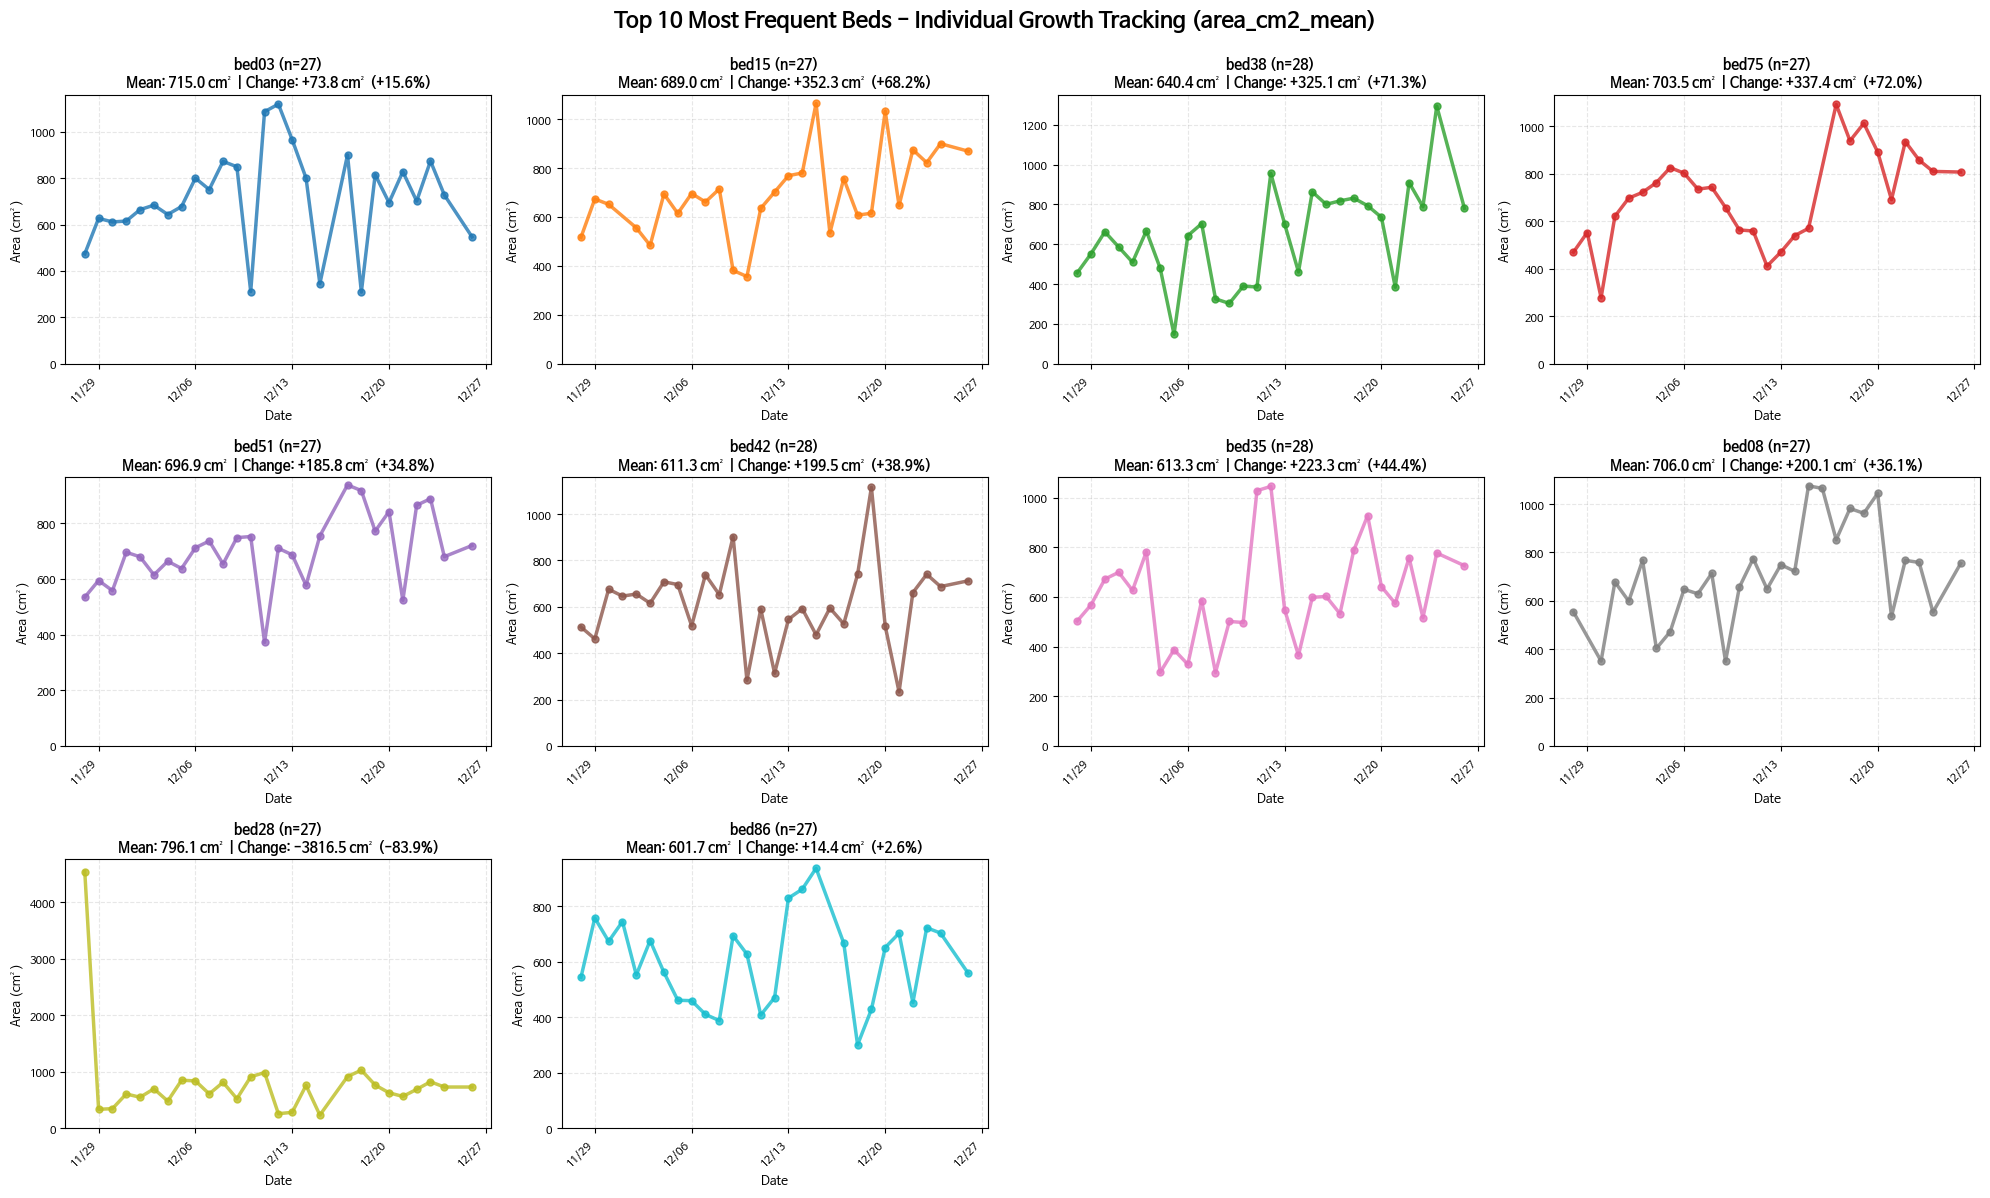

In [ ]:
"""
Plot individual time series for top 10 most frequently appearing beds
Each bed gets its own panel in a 3x4 grid layout
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ============================================================================
# Configuration
# ============================================================================
INPUT_FILE = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/260201_lettuce_index_statical_improved.xlsx"
OUTPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph"

# Top 10 most frequently appearing beds (from first image)
TOP_10_BEDS = ['bed03', 'bed15', 'bed38', 'bed75', 'bed51', 'bed42', 'bed35', 'bed08', 'bed28', 'bed86']

# ============================================================================
# Load Data
# ============================================================================
print("=" * 80)
print("Loading data from Excel...")
print("=" * 80)

df = pd.read_excel(INPUT_FILE, sheet_name='bed_date_stats')

# Extract bed number and date from bed_date column
df['bed'] = df['bed_date'].str.extract(r'(bed\d+)')[0]
df['date'] = df['bed_date'].str.extract(r'_(\d{8})')[0]
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

print(f"\nTotal records: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique beds: {df['bed'].nunique()}")

# ============================================================================
# Filter Top 10 Beds
# ============================================================================
df_top10 = df[df['bed'].isin(TOP_10_BEDS)].copy()
df_top10 = df_top10.sort_values(['bed', 'date'])

print(f"\nFiltered to top 10 beds: {len(df_top10)} records")

# Check data availability for each bed
for bed in TOP_10_BEDS:
    bed_data = df_top10[df_top10['bed'] == bed]
    print(f"  {bed}: {len(bed_data)} records")

# ============================================================================
# Plot Individual Time Series (3x4 grid)
# ============================================================================
print("\n" + "=" * 80)
print("Generating 3x4 individual time series plots...")
print("=" * 80)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Top 10 Most Frequent Beds - Individual Growth Tracking (area_cm2_mean)',
             fontsize=16, fontweight='bold', y=0.995)

# Flatten axes array for easier iteration
axes_flat = axes.flatten()

# Define colors for consistency
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, bed in enumerate(TOP_10_BEDS):
    ax = axes_flat[idx]

    # Get data for this bed
    bed_data = df_top10[df_top10['bed'] == bed].sort_values('date')

    if len(bed_data) > 0:
        # Plot line graph
        ax.plot(bed_data['date'], bed_data['area_cm2_mean'],
               color=colors[idx], linewidth=2.5, marker='o', markersize=5,
               label=bed, alpha=0.8)

        # Calculate statistics
        start_area = bed_data['area_cm2_mean'].iloc[0]
        end_area = bed_data['area_cm2_mean'].iloc[-1]
        mean_area = bed_data['area_cm2_mean'].mean()
        change = end_area - start_area
        change_pct = (change / start_area * 100) if start_area > 0 else 0

        # Title with statistics
        ax.set_title(f'{bed} (n={len(bed_data)})\nMean: {mean_area:.1f} cm² | Change: {change:+.1f} cm² ({change_pct:+.1f}%)',
                    fontsize=10, fontweight='bold')

        # Labels
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('Area (cm²)', fontsize=9)

        # Grid
        ax.grid(True, alpha=0.3, linestyle='--')

        # X-axis format
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

        # Y-axis format
        ax.tick_params(axis='y', labelsize=8)

        # Set y-axis to start from 0 for better comparison
        ax.set_ylim(bottom=0)

    else:
        ax.text(0.5, 0.5, f'{bed}\nNo data available',
               ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('Area (cm²)', fontsize=9)

# Hide extra subplots (we have 10 beds, so 2 empty panels in 3x4 grid)
for idx in range(len(TOP_10_BEDS), 12):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()


#개별 상추의 이미지 보기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import math

# ============================================================================
# Configuration
# ============================================================================
INPUT_FILE = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/features_all_lettuce.xlsx"
OUTPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph"

# Selected beds
SELECTED_BEDS = ['bed03', 'bed38', 'bed75', 'bed28']

# ============================================================================
# Load Data
# ============================================================================
print("=" * 80)
print("Loading original data from Excel...")
print("=" * 80)

df = pd.read_excel(INPUT_FILE, sheet_name='Sheet1')

# Extract bed number from bed_date
df['bed'] = df['bed_date'].str.extract(r'(bed\d+)')[0]

# Extract date from bed_date
df['date'] = df['bed_date'].str.extract(r'_(\d{8})')[0]
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

# Filter only detected instances
df_detected = df[df['n_instances'] > 0].copy()

print(f"\nTotal records: {len(df)}")
print(f"Detected records: {len(df_detected)}")
print(f"Date range: {df_detected['date'].min()} to {df_detected['date'].max()}")

Loading original data from Excel...

Total records: 20443
Detected records: 20443
Date range: 2025-11-28 00:00:00 to 2025-12-26 00:00:00


In [ ]:
# ============================================================================
# Process Each Bed
# ============================================================================
for bed in SELECTED_BEDS:
    print("\n" + "=" * 80)
    print(f"Processing {bed}")
    print("=" * 80)

    # Filter data for this bed
    bed_data = df_detected[df_detected['bed'] == bed].copy()

    if len(bed_data) == 0:
        print(f"⚠️ No data for {bed}, skipping...")
        continue

    print(f"Total records: {len(bed_data)}")

    # Get unique lettuce_ids
    lettuce_ids = sorted(bed_data['lettuce_id'].unique())
    n_ids = len(lettuce_ids)

    print(f"Unique lettuce_ids: {n_ids}")
    print(f"IDs: {lettuce_ids}")

    # Calculate grid size
    n_cols = 4
    n_rows = math.ceil(n_ids / n_cols)

    print(f"Grid layout: {n_rows} rows × {n_cols} cols")

    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    fig.suptitle(f'{bed} - Individual Lettuce Growth Tracking (area_cm2)',
                 fontsize=16, fontweight='bold', y=0.995)

    # Flatten axes array
    if n_rows == 1:
        axes_flat = [axes] if n_cols == 1 else axes.flatten()
    else:
        axes_flat = axes.flatten()

    # Define colors
    colors = plt.cm.tab20(np.linspace(0, 1, n_ids))

    # Plot each lettuce_id
    for idx, lettuce_id in enumerate(lettuce_ids):
        ax = axes_flat[idx]

        # Get data for this lettuce_id
        id_data = bed_data[bed_data['lettuce_id'] == lettuce_id].sort_values('date')

        if len(id_data) > 0:
            # Plot line graph
            ax.plot(id_data['date'], id_data['area_cm2'],
                   color=colors[idx], linewidth=2, marker='o', markersize=4,
                   alpha=0.8)

            # Calculate statistics
            n_records = len(id_data)
            mean_area = id_data['area_cm2'].mean()
            std_area = id_data['area_cm2'].std()
            min_area = id_data['area_cm2'].min()
            max_area = id_data['area_cm2'].max()

            # Check if there's growth data
            if n_records > 1:
                start_area = id_data['area_cm2'].iloc[0]
                end_area = id_data['area_cm2'].iloc[-1]
                change = end_area - start_area
                change_pct = (change / start_area * 100) if start_area > 0 else 0

                # Title with statistics
                ax.set_title(f'{lettuce_id} (n={n_records})\nMean: {mean_area:.1f} | Change: {change:+.1f} cm² ({change_pct:+.1f}%)',
                            fontsize=9, fontweight='bold')
            else:
                ax.set_title(f'{lettuce_id} (n={n_records})\nMean: {mean_area:.1f} cm²',
                            fontsize=9, fontweight='bold')

            # Labels
            ax.set_xlabel('Date', fontsize=8)
            ax.set_ylabel('Area (cm²)', fontsize=8)

            # Grid
            ax.grid(True, alpha=0.3, linestyle='--')

            # X-axis format
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

            # Y-axis format
            ax.tick_params(axis='y', labelsize=7)

            # Set y-axis to start from 0
            ax.set_ylim(bottom=0)

        else:
            ax.text(0.5, 0.5, f'{lettuce_id}\nNo data',
                   ha='center', va='center', fontsize=10, transform=ax.transAxes)
            ax.set_xlabel('Date', fontsize=8)
            ax.set_ylabel('Area (cm²)', fontsize=8)

    # Hide extra subplots
    for idx in range(n_ids, len(axes_flat)):
        axes_flat[idx].axis('off')

    plt.tight_layout()

    # Save figure
    output_file = f"{OUTPUT_DIR}/{bed}_lettuce_id_timeseries.png"
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {output_file}")
    plt.close()

    # ========================================================================
    # Generate summary statistics for this bed
    # ========================================================================
    summary_stats = []

    for lettuce_id in lettuce_ids:
        id_data = bed_data[bed_data['lettuce_id'] == lettuce_id].sort_values('date')

        if len(id_data) > 0:
            n_records = len(id_data)
            mean_area = id_data['area_cm2'].mean()
            std_area = id_data['area_cm2'].std()
            min_area = id_data['area_cm2'].min()
            max_area = id_data['area_cm2'].max()

            if n_records > 1:
                start_area = id_data['area_cm2'].iloc[0]
                end_area = id_data['area_cm2'].iloc[-1]
                change = end_area - start_area
                change_pct = (change / start_area * 100) if start_area > 0 else 0
            else:
                start_area = mean_area
                end_area = mean_area
                change = 0
                change_pct = 0

            summary_stats.append({
                'lettuce_id': lettuce_id,
                'n_records': n_records,
                'start_area': start_area,
                'end_area': end_area,
                'change': change,
                'change_pct': change_pct,
                'mean_area': mean_area,
                'std_area': std_area,
                'min_area': min_area,
                'max_area': max_area
            })

    summary_df = pd.DataFrame(summary_stats)
    summary_df = summary_df.sort_values('mean_area', ascending=False)

    print("\nSummary Statistics:")
    print(summary_df.to_string(index=False))

    # Save summary
    summary_file = f"{OUTPUT_DIR}/{bed}_lettuce_id_summary.csv"
    summary_df.to_csv(summary_file, index=False, encoding='utf-8-sig')
    print(f"✅ Saved summary: {summary_file}")

print("\n" + "=" * 80)
print("All beds processed!")
print("=" * 80)


Processing bed03
Total records: 253
Unique lettuce_ids: 12
IDs: ['b1', 'b2', 'b3', 'b4', 'b5', 'b6', 't1', 't2', 't3', 't4', 't5', 't6']
Grid layout: 3 rows × 4 cols
✅ Saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/bed03_lettuce_id_timeseries.png

Summary Statistics:
lettuce_id  n_records  start_area    end_area      change  change_pct   mean_area   std_area   min_area    max_area
        b1         15  604.373055 1134.833291  530.460236   87.770332 1069.515509 432.533249  78.319172 1698.408961
        t1          5 1004.090544  786.471028 -217.619516  -21.673296 1063.812615 243.593585 786.471028 1452.791192
        b2         22  652.232697 1069.914737  417.682040   64.038807 1033.081942 499.796749  41.413283 2184.062731
        b5         26  703.371710 1063.189895  359.818185   51.156192  869.835310 409.815314  21.281461 1496.746387
        b3         27  587.848435  959.276463

# bed_date의 median 값을 중심으로

In [ ]:
df_b.columns

Index(['image_path', 'base_key', 'lettuce_id', 'bed_date', 'n_instances',
       'conf', 'brightness_mean', 'blur_score', 'area_px', 'area_cm2',
       'px_per_mm_x', 'px_per_mm_y', 'mm_per_px', 'cyl_ok', 'cyl_diam_px',
       'front_height_cm', 'area_front', 'aspect_ratio', 'bottom_flatness',
       'core_prominence', 'bbox_w', 'bbox_h', 'perimeter_px', 'circularity',
       'solidity', 'concavity', 'curvature', 'roughness', 'best_instance',
       'position_group', 'bed', 'date', 'px_per_mm', 'bed_num'],
      dtype='object')

In [ ]:
IMPORTANT_FEATURES = [
    'brightness_mean',
    'area_px',
    'area_cm2',
    'px_per_mm',
    'front_height_cm',
    'area_front',
    'aspect_ratio',
    'bottom_flatness',
    'core_prominence',
    'perimeter_px',
    'circularity',
    'solidity',
    'curvature',
    'roughness'
]

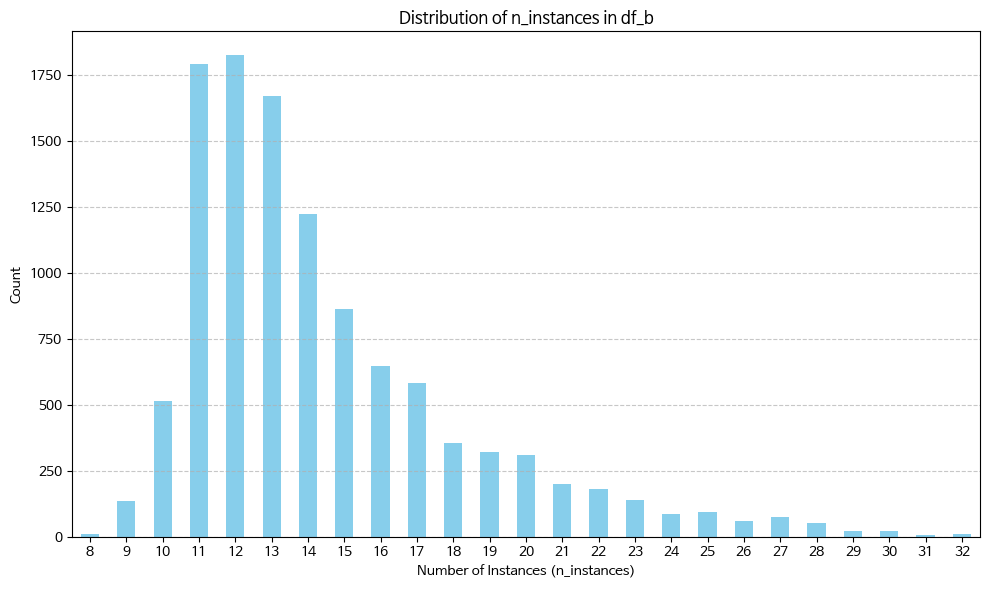

In [ ]:
import matplotlib.pyplot as plt

# Calculate the count of each 'n_instances' value
instance_counts = df_b['n_instances'].value_counts().sort_index()

# Create the bar plot
plt.figure(figsize=(10, 6))
instance_counts.plot(kind='bar', color='skyblue')

# Add title and labels
plt.title('Distribution of n_instances in df_b')
plt.xlabel('Number of Instances (n_instances)')
plt.ylabel('Count')
plt.xticks(rotation=0) # Ensure x-axis labels are horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

# 260202 n_instance=10-14로 고정하고, 급락 제거한 엑셀 다시생성

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats as scipy_stats

# 경로 설정
excel_file = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/features_all_lettuce.xlsx'
output_file = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/filtered_lettuce_data.xlsx'

print("="*80)
print("데이터 로드 및 전처리")
print("="*80)

# 데이터 로드
df = pd.read_excel(excel_file)
print(f"\n원본 데이터 shape: {df.shape}")

# bed_str 생성
df['bed_str'] = df['bed_date'].str.extract(r'(bed\d+)')[0]

# date 변환
df['date_dt'] = pd.to_datetime(df['date'].astype(str), format='%Y%m%d', errors='coerce')

# 유효 데이터만 필터링
df_valid = df[(df['date_dt'].notna()) & (df['area_cm2'].notna()) & (df['area_cm2'] > 0)].copy()
print(f"유효 데이터: {df_valid.shape}")

# Step 1: n_instances = 10-14만 필터링
print("\n" + "="*80)
print("Step 1: n_instances = 10-14 필터링")
print("="*80)

df_filtered = df_valid[(df_valid['n_instances'] >= 10) & (df_valid['n_instances'] <= 14)].copy()
print(f"n_instances=10-14 필터링 후: {df_filtered.shape}")
print(f"제거된 데이터: {len(df_valid) - len(df_filtered)}개")

# Step 2: 같은 lettuce_id에 대해 어제보다 50% 이상 낮은 값 제거
print("\n" + "="*80)
print("Step 2: 시계열 급감소 데이터 제거 (어제 대비 50% 이상 하락)")
print("="*80)

# bed_lettuce_id 생성 (bed_str + lettuce_id)
df_filtered['bed_lettuce_id'] = df_filtered['bed_str'] + '_' + df_filtered['lettuce_id'].astype(str)

# 날짜순 정렬
df_filtered = df_filtered.sort_values(['bed_lettuce_id', 'date_dt']).reset_index(drop=True)

# 이전 날짜의 area_cm2 계산
df_filtered['prev_area_cm2'] = df_filtered.groupby('bed_lettuce_id')['area_cm2'].shift(1)

# 변화율 계산 (현재값 / 이전값)
df_filtered['area_change_ratio'] = df_filtered['area_cm2'] / df_filtered['prev_area_cm2']

# 50% 이상 하락한 데이터 찾기 (변화율 < 0.5)
# 첫 번째 데이터는 제외 (prev_area_cm2가 NaN)
mask_drop = (df_filtered['area_change_ratio'] < 0.5) & (df_filtered['prev_area_cm2'].notna())

print(f"\n어제 대비 50% 이상 하락한 데이터:")
print(f"  총 개수: {mask_drop.sum()}개")
print(f"  비율: {mask_drop.sum() / len(df_filtered) * 100:.2f}%")

# 하락 데이터 샘플 출력
if mask_drop.sum() > 0:
    drop_samples = df_filtered[mask_drop][['bed_lettuce_id', 'date_dt', 'area_cm2', 'prev_area_cm2', 'area_change_ratio']].head(10)
    print("\n하락 데이터 샘플 (상위 10개):")
    print(drop_samples.to_string(index=False))

# 급감소 데이터 제거
df_cleaned = df_filtered[~mask_drop].copy()

print(f"\n급감소 데이터 제거 후: {df_cleaned.shape}")
print(f"제거된 데이터: {mask_drop.sum()}개")

# Step 3: 최종 데이터 통계
print("\n" + "="*80)
print("최종 데이터 통계")
print("="*80)

print(f"\n최종 shape: {df_cleaned.shape}")
print(f"  행(rows): {df_cleaned.shape[0]}")
print(f"  열(columns): {df_cleaned.shape[1]}")

print(f"\n데이터 감소:")
print(f"  원본: {df.shape[0]}개")
print(f"  유효 데이터: {df_valid.shape[0]}개 ({df_valid.shape[0]/df.shape[0]*100:.1f}%)")
print(f"  n_instances 필터링: {df_filtered.shape[0]}개 ({df_filtered.shape[0]/df.shape[0]*100:.1f}%)")
print(f"  최종: {df_cleaned.shape[0]}개 ({df_cleaned.shape[0]/df.shape[0]*100:.1f}%)")

print(f"\n고유 값:")
print(f"  고유 bed 수: {df_cleaned['bed_str'].nunique()}")
print(f"  고유 lettuce_id 수: {df_cleaned['bed_lettuce_id'].nunique()}")
print(f"  날짜 범위: {df_cleaned['date_dt'].min()} ~ {df_cleaned['date_dt'].max()}")

print(f"\narea_cm2 통계:")
print(df_cleaned['area_cm2'].describe())

# Step 4: 베드별 추세 분석
print("\n" + "="*80)
print("베드별 시계열 추세 분석")
print("="*80)

# 베드별 날짜별 평균 계산
bed_daily = df_cleaned.groupby(['bed_str', 'date_dt']).agg({
    'area_cm2': ['mean', 'median', 'std', 'count']
}).reset_index()
bed_daily.columns = ['bed_str', 'date_dt', 'area_mean', 'area_median', 'area_std', 'count']

# 각 베드별 선형 회귀 분석
bed_trends = []

for bed_name in df_cleaned['bed_str'].unique():
    bed_data = bed_daily[bed_daily['bed_str'] == bed_name].copy()
    bed_data = bed_data.sort_values('date_dt')

    if len(bed_data) < 3:  # 최소 3개 이상의 데이터 포인트 필요
        continue

    x = np.arange(len(bed_data))

    # Mean 추세
    slope_mean, intercept_mean, r_mean, p_mean, se_mean = scipy_stats.linregress(x, bed_data['area_mean'])

    # Median 추세
    slope_median, intercept_median, r_median, p_median, se_median = scipy_stats.linregress(x, bed_data['area_median'])

    # 추세 판정
    trend_mean = 'increase' if (slope_mean > 0 and p_mean < 0.05) else ('decrease' if (slope_mean < 0 and p_mean < 0.05) else 'none')
    trend_median = 'increase' if (slope_median > 0 and p_median < 0.05) else ('decrease' if (slope_median < 0 and p_median < 0.05) else 'none')

    # 추세 점수 계산 (R² 기반)
    # Mean과 Median의 R² 평균, 유의한 증가 추세에 가중치
    trend_score = (r_mean**2 + r_median**2) / 2
    if trend_mean == 'increase' and trend_median == 'increase':
        trend_score *= 1.5  # 두 지표 모두 증가 시 가중치
    elif trend_mean == 'increase' or trend_median == 'increase':
        trend_score *= 1.2  # 하나만 증가 시 가중치

    bed_trends.append({
        'bed_str': bed_name,
        'n_days': len(bed_data),
        'n_data_points': bed_data['count'].sum(),
        'mean_avg': bed_data['area_mean'].mean(),
        'median_avg': bed_data['area_median'].mean(),
        'slope_mean': slope_mean,
        'r2_mean': r_mean**2,
        'p_mean': p_mean,
        'trend_mean': trend_mean,
        'slope_median': slope_median,
        'r2_median': r_median**2,
        'p_median': p_median,
        'trend_median': trend_median,
        'trend_score': trend_score
    })

bed_trends_df = pd.DataFrame(bed_trends)
bed_trends_df = bed_trends_df.sort_values('trend_score', ascending=False)

print(f"\n분석된 베드 수: {len(bed_trends_df)}")
print(f"\n상위 20개 베드 (trend_score 기준):")
print(bed_trends_df.head(20).to_string(index=False))

# Step 5: 상위 10개 베드 선정
print("\n" + "="*80)
print("시계열 추세가 가장 명확한 상위 10개 베드")
print("="*80)

top10_beds = bed_trends_df.head(10)['bed_str'].tolist()

print(f"\n선정된 상위 10개 베드:")
for idx, bed_name in enumerate(top10_beds, 1):
    bed_info = bed_trends_df[bed_trends_df['bed_str'] == bed_name].iloc[0]
    print(f"{idx:2d}. {bed_name}: "
          f"Score={bed_info['trend_score']:.3f}, "
          f"R²_mean={bed_info['r2_mean']:.3f}, "
          f"R²_median={bed_info['r2_median']:.3f}, "
          f"Trend={bed_info['trend_mean']}/{bed_info['trend_median']}, "
          f"N_days={bed_info['n_days']}, "
          f"N_data={bed_info['n_data_points']}")

# Step 6: 엑셀 파일 저장
print("\n" + "="*80)
print("엑셀 파일 저장")
print("="*80)

# 불필요한 컬럼 제거 (분석용 컬럼)
columns_to_drop = ['prev_area_cm2', 'area_change_ratio']
df_output = df_cleaned.drop(columns=columns_to_drop, errors='ignore')

# 엑셀 파일로 저장
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # Sheet 1: 전체 필터링된 데이터
    df_output.to_excel(writer, sheet_name='Filtered_Data', index=False)

    # Sheet 2: 베드별 추세 분석 결과
    bed_trends_df.to_excel(writer, sheet_name='Bed_Trends', index=False)

    # Sheet 3: 상위 10개 베드 데이터만
    df_top10 = df_output[df_output['bed_str'].isin(top10_beds)]
    df_top10.to_excel(writer, sheet_name='Top10_Beds_Data', index=False)

    # Sheet 4: 상위 10개 베드 일별 통계
    bed_daily_top10 = bed_daily[bed_daily['bed_str'].isin(top10_beds)]
    bed_daily_top10.to_excel(writer, sheet_name='Top10_Beds_Daily', index=False)

print(f"\n엑셀 파일 저장 완료: {output_file}")
print(f"\nSheet 구성:")
print(f"  1. Filtered_Data: 전체 필터링된 데이터 ({len(df_output)}개)")
print(f"  2. Bed_Trends: 베드별 추세 분석 결과 ({len(bed_trends_df)}개 베드)")
print(f"  3. Top10_Beds_Data: 상위 10개 베드 데이터만 ({len(df_top10)}개)")
print(f"  4. Top10_Beds_Daily: 상위 10개 베드 일별 통계 ({len(bed_daily_top10)}개)")

print("\n" + "="*80)
print("분석 완료!")
print("="*80)

# 요약 정보 저장
summary = {
    'original_shape': df.shape,
    'valid_shape': df_valid.shape,
    'n_instances_filtered_shape': df_filtered.shape,
    'final_shape': df_cleaned.shape,
    'removed_by_n_instances': len(df_valid) - len(df_filtered),
    'removed_by_drop': mask_drop.sum(),
    'unique_beds': df_cleaned['bed_str'].nunique(),
    'unique_lettuce_ids': df_cleaned['bed_lettuce_id'].nunique(),
    'date_range': f"{df_cleaned['date_dt'].min()} ~ {df_cleaned['date_dt'].max()}",
    'top10_beds': top10_beds
}

import json
with open('/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/filtering_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False, default=str)

print(f"\n요약 정보 저장: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/filtering_summary.json")


데이터 로드 및 전처리

원본 데이터 shape: (20443, 33)
유효 데이터: (20443, 35)

Step 1: n_instances = 10-14 필터링
n_instances=10-14 필터링 후: (12587, 35)
제거된 데이터: 7856개

Step 2: 시계열 급감소 데이터 제거 (어제 대비 50% 이상 하락)

어제 대비 50% 이상 하락한 데이터:
  총 개수: 930개
  비율: 7.39%

하락 데이터 샘플 (상위 10개):
bed_lettuce_id    date_dt   area_cm2  prev_area_cm2  area_change_ratio
      bed00_b3 2025-12-13  28.629196     903.276323           0.031695
      bed00_b6 2025-12-06  54.650702     932.352886           0.058616
      bed00_b6 2025-12-14  90.992360    1129.478306           0.080561
      bed00_t2 2025-12-21  94.054829     509.466799           0.184614
      bed00_t6 2025-12-14 146.413039     577.261214           0.253634
      bed01_b3 2025-12-15 128.575030    1049.936841           0.122460
      bed01_b5 2025-12-15  35.000029     899.404950           0.038915
      bed01_b6 2025-11-29  52.785883     205.905878           0.256359
      bed01_b6 2025-12-03  50.979157     907.969011           0.056146
      bed01_b6 2025-12-07 179.2894

데이터 로드

상위 10개 베드: ['bed10', 'bed74', 'bed03', 'bed05', 'bed84', 'bed76', 'bed29', 'bed51', 'bed90', 'bed79']

일별 통계 데이터: (155, 6)

상위 10개 베드 시계열 시각화


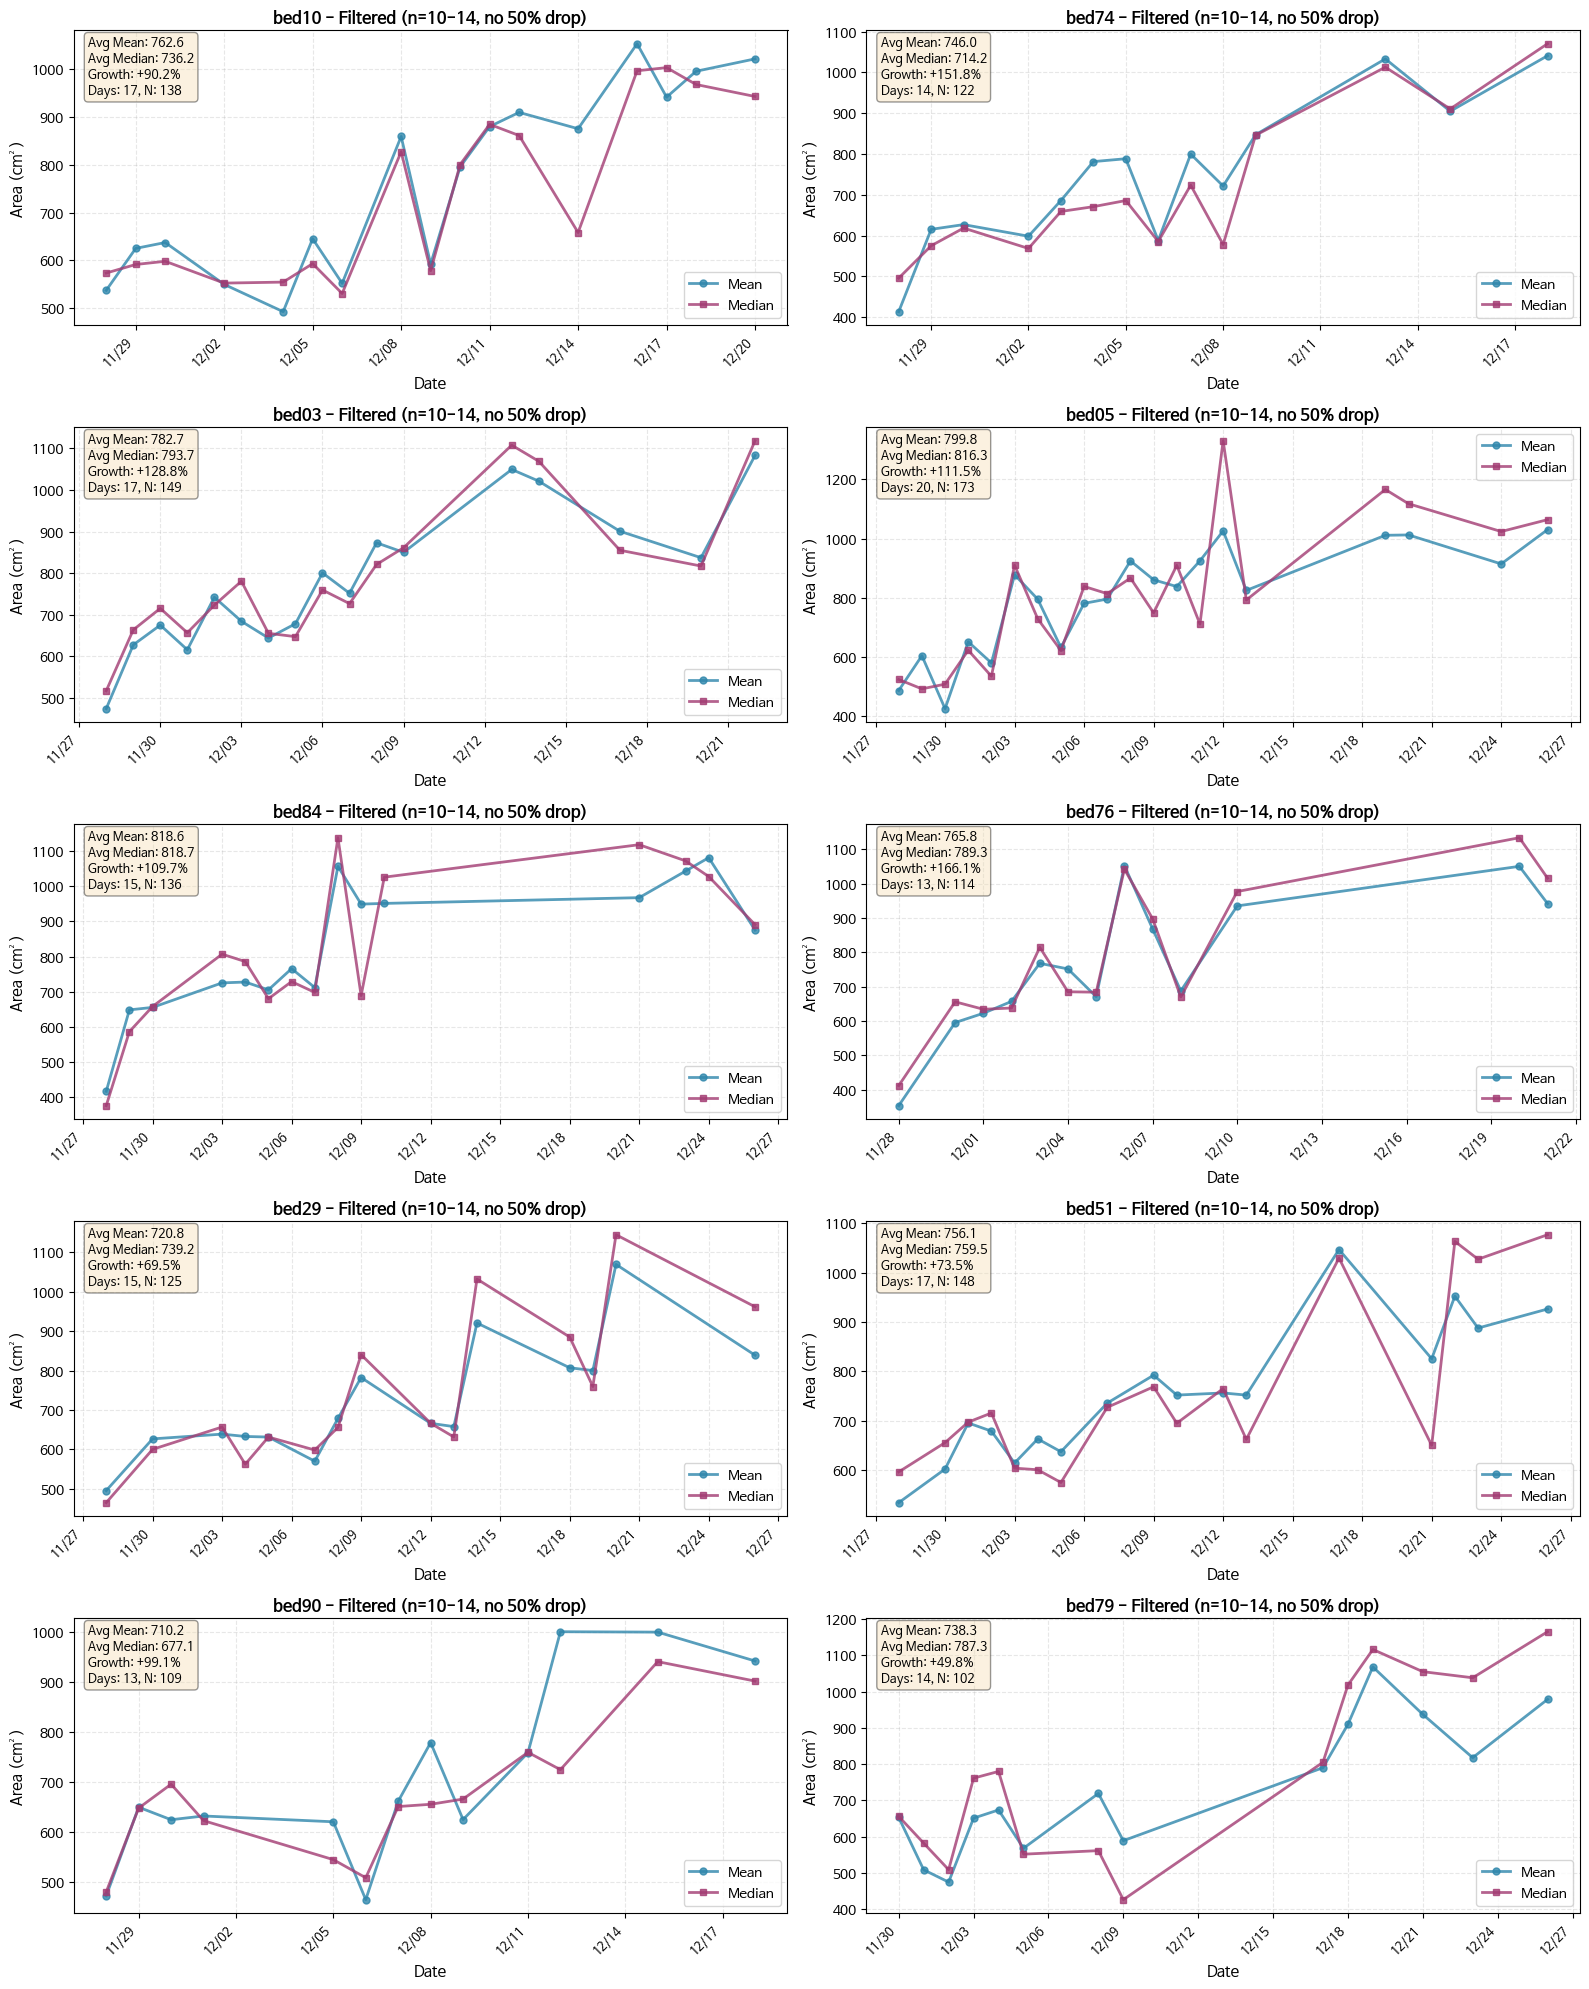

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json

# 경로 설정
excel_file = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/filtered_lettuce_data.xlsx'
summary_file = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/filtering_summary.json'

print("="*80)
print("데이터 로드")
print("="*80)

# 요약 정보 로드
with open(summary_file, 'r', encoding='utf-8') as f:
    summary = json.load(f)

top10_beds = summary['top10_beds']
print(f"\n상위 10개 베드: {top10_beds}")

# 엑셀 파일에서 상위 10개 베드 일별 통계 로드
bed_daily = pd.read_excel(excel_file, sheet_name='Top10_Beds_Daily')
bed_daily['date_dt'] = pd.to_datetime(bed_daily['date_dt'])

print(f"\n일별 통계 데이터: {bed_daily.shape}")

# 시각화
print("\n" + "="*80)
print("상위 10개 베드 시계열 시각화")
print("="*80)

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, bed_name in enumerate(top10_beds):
    ax = axes[idx]

    # 해당 베드 데이터 추출
    bed_data = bed_daily[bed_daily['bed_str'] == bed_name].copy()
    bed_data = bed_data.sort_values('date_dt')

    if len(bed_data) == 0:
        ax.text(0.5, 0.5, f'{bed_name}\nNo Data',
                ha='center', va='center', fontsize=12)
        ax.set_title(f'{bed_name}', fontsize=12, fontweight='bold')
        continue

    # 시계열 플롯
    ax.plot(bed_data['date_dt'], bed_data['area_mean'],
            marker='o', label='Mean', linewidth=2, markersize=5, alpha=0.8, color='#2E86AB')
    ax.plot(bed_data['date_dt'], bed_data['area_median'],
            marker='s', label='Median', linewidth=2, markersize=5, alpha=0.8, color='#A23B72')

    # 표준편차 영역 (선택적)
    # ax.fill_between(bed_data['date_dt'],
    #                  bed_data['area_mean'] - bed_data['area_std'],
    #                  bed_data['area_mean'] + bed_data['area_std'],
    #                  alpha=0.2, color='#2E86AB')

    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Area (cm²)', fontsize=11)
    ax.set_title(f'{bed_name} - Filtered (n=10-14, no 50% drop)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')

    # 날짜 포맷
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

    # 통계 정보 추가
    mean_avg = bed_data['area_mean'].mean()
    median_avg = bed_data['area_median'].mean()
    data_points = bed_data['count'].sum()
    n_days = len(bed_data)

    # 증가율 계산
    if len(bed_data) >= 2:
        first_mean = bed_data['area_mean'].iloc[0]
        last_mean = bed_data['area_mean'].iloc[-1]
        growth_rate = ((last_mean - first_mean) / first_mean) * 100

        ax.text(0.02, 0.98,
                f'Avg Mean: {mean_avg:.1f}\n'
                f'Avg Median: {median_avg:.1f}\n'
                f'Growth: {growth_rate:+.1f}%\n'
                f'Days: {n_days}, N: {data_points}',
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

plt.tight_layout()
plt.show()


상위 10개 베드: ['bed10', 'bed74', 'bed03', 'bed05', 'bed84', 'bed76', 'bed29', 'bed51', 'bed90', 'bed79']

전체 데이터: (11657, 36)
상위 10개 베드 데이터: (1316, 36)

Step 1: 상위 2번째 값 (2nd highest) 계산

상위 2번째 값 통계 데이터: (155, 4)
샘플 데이터:
  bed_str    date_dt     area_2nd  count
0   bed03 2025-11-28   652.232697     11
1   bed03 2025-11-29   767.268928     10
2   bed03 2025-11-30   811.418402      8
3   bed03 2025-12-01   773.270664     11
4   bed03 2025-12-02   906.646849      7
5   bed03 2025-12-03   821.622068      9
6   bed03 2025-12-04   824.432162      8
7   bed03 2025-12-05   840.244306      9
8   bed03 2025-12-06  1125.864962     10
9   bed03 2025-12-07   913.112630     11

Step 4: 상위 2번째 값 시각화

시각화 저장: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/timeseries_2nd_highest_area_cm2.png


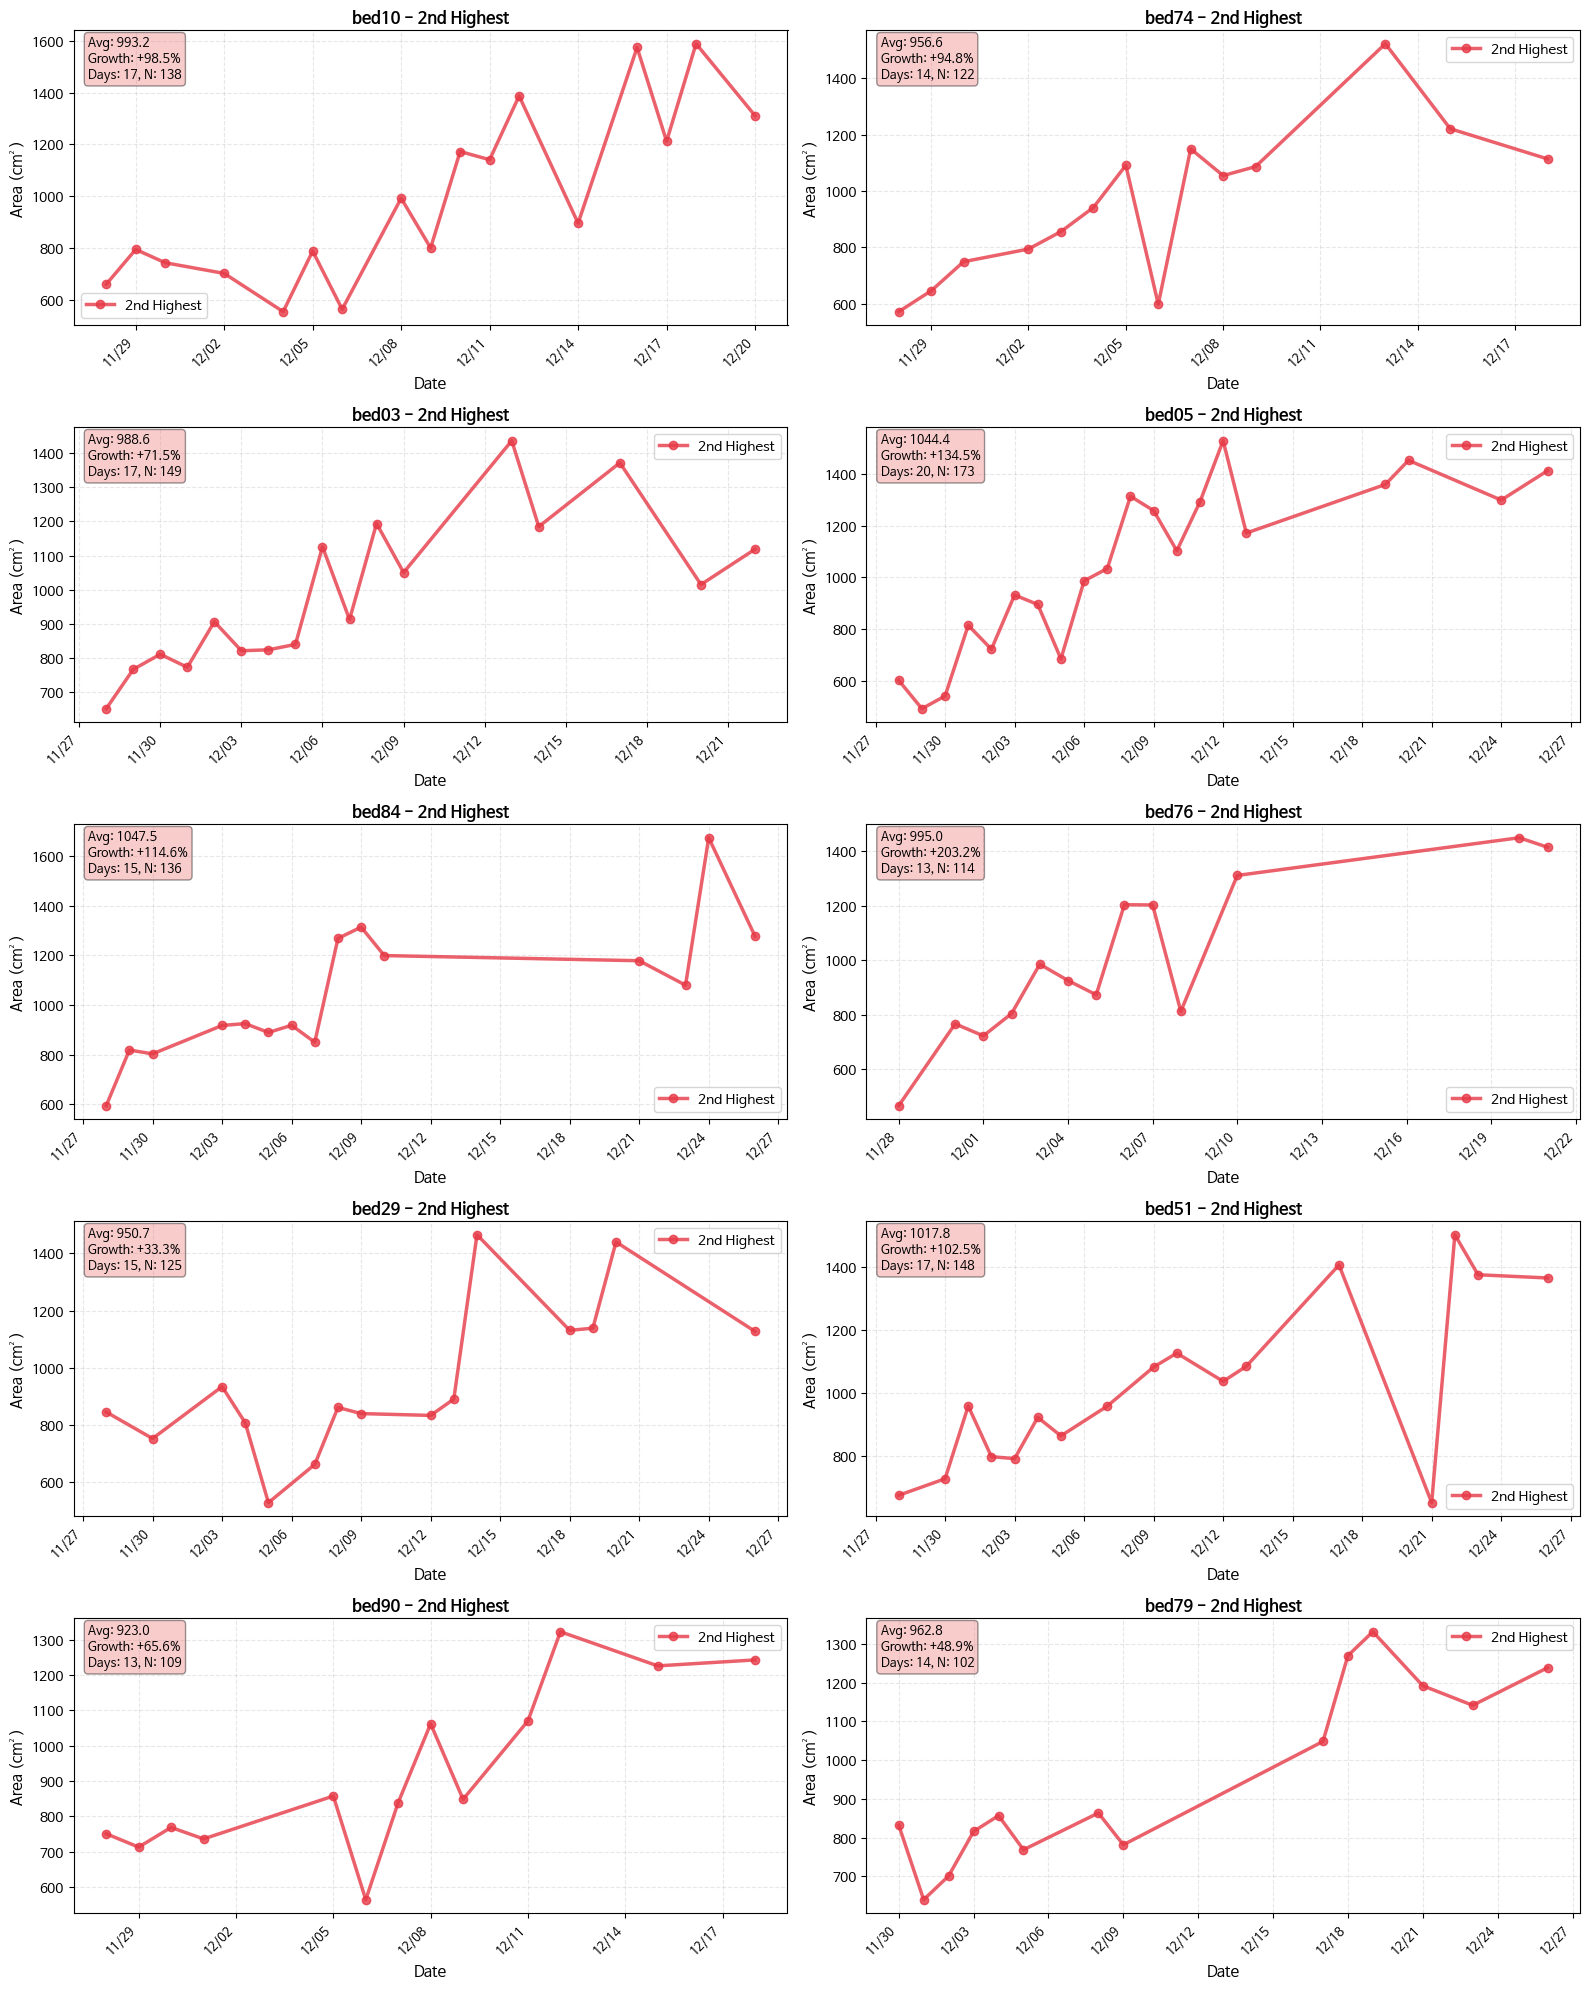

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json

# ========== 경로 설정 ==========
# 요약 정보 로드
with open(summary_file, 'r', encoding='utf-8') as f:
    summary = json.load(f)

top10_beds = summary['top10_beds']
print(f"\n상위 10개 베드: {top10_beds}")

# 엑셀 파일에서 전체 필터링된 데이터 로드
df = pd.read_excel(excel_file, sheet_name='Filtered_Data')
print(f"\n전체 데이터: {df.shape}")

# 상위 10개 베드만 필터링
df_top10 = df[df['bed_str'].isin(top10_beds)].copy()
print(f"상위 10개 베드 데이터: {df_top10.shape}")

# ========== 함수 정의 ==========

def calculate_2nd_highest(group):
    """그룹 내에서 상위 2번째 값 계산"""
    values = group.sort_values(ascending=False)
    if len(values) >= 2:
        return values.iloc[1]  # 2번째로 큰 값
    elif len(values) == 1:
        return values.iloc[0]  # 데이터가 1개면 그 값 반환
    else:
        return np.nan

def calculate_daily_stats_custom(df_group, stat_func, stat_name):
    """bed_date별 커스텀 통계 계산"""
    daily_stats = df_group.groupby(['bed_str', 'date_dt']).agg({
        'area_cm2': [stat_func, 'count']
    }).reset_index()
    daily_stats.columns = ['bed_str', 'date_dt', f'area_{stat_name}', 'count']
    return daily_stats

# ========== Step 1: 상위 2번째 값 계산 ==========
print("\n" + "="*80)
print("Step 1: 상위 2번째 값 (2nd highest) 계산")
print("="*80)

stats_2nd = calculate_daily_stats_custom(df_top10, calculate_2nd_highest, '2nd')
print(f"\n상위 2번째 값 통계 데이터: {stats_2nd.shape}")
print(f"샘플 데이터:")
print(stats_2nd.head(10))


# ========== Step 3: 시각화 함수 정의 ==========

def plot_timeseries(stats_df, value_col, title_suffix, output_file, top10_beds):
    """시계열 그래프 생성"""
    fig, axes = plt.subplots(5, 2, figsize=(16, 20))
    axes = axes.flatten()

    for idx, bed_name in enumerate(top10_beds):
        ax = axes[idx]

        # 해당 베드 데이터 추출
        bed_data = stats_df[stats_df['bed_str'] == bed_name].copy()
        bed_data = bed_data.sort_values('date_dt')

        if len(bed_data) == 0:
            ax.text(0.5, 0.5, f'{bed_name}\nNo Data',
                    ha='center', va='center', fontsize=12)
            ax.set_title(f'{bed_name}', fontsize=12, fontweight='bold')
            continue

        # 시계열 플롯
        ax.plot(bed_data['date_dt'], bed_data[value_col],
                marker='o', linewidth=2.5, markersize=6, alpha=0.8,
                color='#E63946', label=title_suffix)

        ax.set_xlabel('Date', fontsize=11)
        ax.set_ylabel('Area (cm²)', fontsize=11)
        ax.set_title(f'{bed_name} - {title_suffix}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10, loc='best')
        ax.grid(True, alpha=0.3, linestyle='--')

        # 날짜 포맷
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

        # 통계 정보 추가
        value_avg = bed_data[value_col].mean()
        data_points = bed_data['count'].sum()
        n_days = len(bed_data)

        # 증가율 계산
        if len(bed_data) >= 2:
            first_value = bed_data[value_col].iloc[0]
            last_value = bed_data[value_col].iloc[-1]
            growth_rate = ((last_value - first_value) / first_value) * 100

            ax.text(0.02, 0.98,
                    f'Avg: {value_avg:.1f}\n'
                    f'Growth: {growth_rate:+.1f}%\n'
                    f'Days: {n_days}, N: {data_points}',
                    transform=ax.transAxes, fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.4))

    plt.tight_layout()
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    print(f"\n시각화 저장: {output_file}")

# ========== Step 4: 상위 2번째 값 시각화 ==========
print("\n" + "="*80)
print("Step 4: 상위 2번째 값 시각화")
print("="*80)

# Define the output file path for the plot
output_plot_file = f"{OUTPUT_DIR}/timeseries_2nd_highest_area_cm2.png"

plot_timeseries(stats_2nd, 'area_2nd', '2nd Highest', output_plot_file, top10_beds)


#이제 다른 지표들 시각화 좀

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.backends.backend_pdf import PdfPages
import json

# ========== 경로 설정 ==========
excel_file = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/filtered_lettuce_data.xlsx'
summary_file = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/filtering_summary.json'
output_pdf_file = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/top10_beds_multiple_metrics.pdf'

print("="*80)
print("데이터 로드")
print("="*80)

# 요약 정보 로드
with open(summary_file, 'r', encoding='utf-8') as f:
    summary = json.load(f)

top10_beds = summary['top10_beds']
print(f"\n상위 10개 베드: {top10_beds}")

# 엑셀 파일에서 상위 10개 베드 데이터 로드
bed_daily = pd.read_excel(excel_file, sheet_name='Top10_Beds_Data')
bed_daily['date_dt'] = pd.to_datetime(bed_daily['date_dt'])

print(f"\n데이터 shape: {bed_daily.shape}")
print(f"\n컬럼 목록:")
print(bed_daily.columns.tolist())

# ========== 그래프로 그릴 지표 리스트 ==========
wantgraph = ['area_px', 'mm_per_px', 'front_height_cm', 'area_front',
             'aspect_ratio', 'bottom_flatness', 'core_prominence',
             'perimeter_px', 'circularity', 'solidity',
             'concavity', 'curvature', 'roughness']

print(f"\n그래프로 그릴 지표 수: {len(wantgraph)}")
print(f"지표 목록: {wantgraph}")

# ========== 지표별 단위 및 레이블 매핑 ==========
metric_info = {
    'area_px': {'ylabel': 'Area (pixels)', 'color_mean': '#2E86AB', 'color_median': '#A23B72'},
    'mm_per_px': {'ylabel': 'mm per pixel', 'color_mean': '#2E86AB', 'color_median': '#A23B72'},
    'front_height_cm': {'ylabel': 'Height (cm)', 'color_mean': '#2E86AB', 'color_median': '#A23B72'},
    'area_front': {'ylabel': 'Area (cm²)', 'color_mean': '#2E86AB', 'color_median': '#A23B72'},
    'aspect_ratio': {'ylabel': 'Aspect Ratio', 'color_mean': '#2E86AB', 'color_median': '#A23B72'},
    'bottom_flatness': {'ylabel': 'Bottom Flatness', 'color_mean': '#2E86AB', 'color_median': '#A23B72'},
    'core_prominence': {'ylabel': 'Core Prominence', 'color_mean': '#2E86AB', 'color_median': '#A23B72'},
    'perimeter_px': {'ylabel': 'Perimeter (pixels)', 'color_mean': '#2E86AB', 'color_median': '#A23B72'},
    'circularity': {'ylabel': 'Circularity', 'color_mean': '#2E86AB', 'color_median': '#A23B72'},
    'solidity': {'ylabel': 'Solidity', 'color_mean': '#2E86AB', 'color_median': '#A23B72'},
    'concavity': {'ylabel': 'Concavity', 'color_mean': '#2E86AB', 'color_median': '#A23B72'},
    'curvature': {'ylabel': 'Curvature', 'color_mean': '#2E86AB', 'color_median': '#A23B72'},
    'roughness': {'ylabel': 'Roughness', 'color_mean': '#2E86AB', 'color_median': '#A23B72'}
}

# ========== 함수 정의: 베드별 일별 통계 계산 ==========
def calculate_daily_stats(df, metric_name):
    """bed_str과 date_dt별로 mean, median, std, count 계산"""
    daily_stats = df.groupby(['bed_str', 'date_dt']).agg({
        metric_name: ['mean', 'median', 'std', 'count']
    }).reset_index()
    daily_stats.columns = ['bed_str', 'date_dt', f'{metric_name}_mean',
                            f'{metric_name}_median', f'{metric_name}_std', 'count']
    return daily_stats

# ========== 함수 정의: 지표별 시계열 그래프 생성 ==========
def plot_metric_timeseries(metric_name, bed_daily_stats, top10_beds, metric_info):
    """특정 지표에 대한 상위 10개 베드 시계열 그래프 생성"""

    fig, axes = plt.subplots(5, 2, figsize=(16, 20))
    axes = axes.flatten()

    ylabel = metric_info[metric_name]['ylabel']
    color_mean = metric_info[metric_name]['color_mean']
    color_median = metric_info[metric_name]['color_median']

    for idx, bed_name in enumerate(top10_beds):
        ax = axes[idx]

        # 해당 베드 데이터 추출
        bed_data = bed_daily_stats[bed_daily_stats['bed_str'] == bed_name].copy()
        bed_data = bed_data.sort_values('date_dt')

        if len(bed_data) == 0:
            ax.text(0.5, 0.5, f'{bed_name}\nNo Data',
                    ha='center', va='center', fontsize=12)
            ax.set_title(f'{bed_name}', fontsize=12, fontweight='bold')
            continue

        # Mean과 Median 컬럼 확인
        mean_col = f'{metric_name}_mean'
        median_col = f'{metric_name}_median'

        # 시계열 플롯
        if mean_col in bed_data.columns:
            ax.plot(bed_data['date_dt'], bed_data[mean_col],
                    marker='o', label='Mean', linewidth=2, markersize=5,
                    alpha=0.8, color=color_mean)

        if median_col in bed_data.columns:
            ax.plot(bed_data['date_dt'], bed_data[median_col],
                    marker='s', label='Median', linewidth=2, markersize=5,
                    alpha=0.8, color=color_median)

        ax.set_xlabel('Date', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'{bed_name} - {metric_name}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10, loc='best')
        ax.grid(True, alpha=0.3, linestyle='--')

        # 날짜 포맷
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

        # 통계 정보 추가
        if mean_col in bed_data.columns and median_col in bed_data.columns:
            mean_avg = bed_data[mean_col].mean()
            median_avg = bed_data[median_col].mean()
            data_points = bed_data['count'].sum()
            n_days = len(bed_data)

            # 증가율 계산 (Mean 기준)
            if len(bed_data) >= 2:
                first_mean = bed_data[mean_col].iloc[0]
                last_mean = bed_data[mean_col].iloc[-1]

                if first_mean != 0:
                    growth_rate = ((last_mean - first_mean) / first_mean) * 100
                else:
                    growth_rate = 0

                ax.text(0.02, 0.98,
                        f'Avg Mean: {mean_avg:.2f}\n'
                        f'Avg Median: {median_avg:.2f}\n'
                        f'Growth: {growth_rate:+.1f}%\n'
                        f'Days: {n_days}, N: {data_points}',
                        transform=ax.transAxes, fontsize=9, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

    plt.tight_layout()
    return fig

# ========== PDF 생성 ==========
print("\n" + "="*80)
print("PDF 생성 시작")
print("="*80)

with PdfPages(output_pdf_file) as pdf:
    for i, metric_name in enumerate(wantgraph, 1):
        print(f"\n[{i}/{len(wantgraph)}] {metric_name} 그래프 생성 중...")

        # 해당 지표가 데이터에 존재하는지 확인
        if metric_name not in bed_daily.columns:
            print(f"  ⚠️  경고: '{metric_name}' 컬럼이 데이터에 없습니다. 건너뜁니다.")
            continue

        # 일별 통계 계산
        bed_daily_stats = calculate_daily_stats(bed_daily, metric_name)

        # 그래프 생성
        fig = plot_metric_timeseries(metric_name, bed_daily_stats, top10_beds, metric_info)

        # 전체 제목 추가
        fig.suptitle(f'Top 10 Bed Visualization - {metric_name}',
                     fontsize=16, fontweight='bold', y=0.995)

        # PDF에 저장
        pdf.savefig(fig, dpi=150, bbox_inches='tight')
        plt.close(fig)

        print(f"  ✓ {metric_name} 그래프 완료")

print("\n" + "="*80)
print(f"PDF 저장 완료: {output_pdf_file}")
print("="*80)

# ========== 요약 정보 출력 ==========
print("\n" + "="*80)
print("요약 정보")
print("="*80)
print(f"총 그래프 수: {len(wantgraph)}개")
print(f"상위 10개 베드: {', '.join(top10_beds)}")
print(f"PDF 파일: {output_pdf_file}")
print("\n분석 완료!")

#찐찐 마지막으로 다시 날짜별로만 비교해 보자. 그냥 필터안한 원본과 뭐가 다를지..

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================================
# 데이터 로드
# ============================================================================
print("=" * 80)
print("데이터 로드 중...")
print("=" * 80)

excel_file = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/filtered_lettuce_data.xlsx"

df = pd.read_excel(excel_file, sheet_name="Top10_Beds_Data")

print(f"\n데이터 shape: {df.shape}")
print(f"\n컬럼 목록:")
print(df.columns.tolist())
print(f"\nposition_group 값: {df['position_group'].unique()}")

# ============================================================================
# 데이터 분리 및 날짜 변환
# ============================================================================
df_b = df[df['position_group'] == "b"].copy()
df_t = df[df['position_group'] == "t"].copy()

# date_dt 컬럼 사용 (이미 datetime 형식)
if 'date_dt' in df.columns:
    df_b['date'] = pd.to_datetime(df_b['date_dt'])
    df_t['date'] = pd.to_datetime(df_t['date_dt'])
elif 'date' in df.columns:
    df_b['date'] = pd.to_datetime(df_b['date'])
    df_t['date'] = pd.to_datetime(df_t['date'])
else:
    print("ERROR: 날짜 컬럼을 찾을 수 없습니다!")
    exit(1)

print(f"\n앞열(b*): {len(df_b)}행")
print(f"뒷열(t*): {len(df_t)}행")
print(f"\n앞열 날짜 범위: {df_b['date'].min()} ~ {df_b['date'].max()}")
print(f"뒷열 날짜 범위: {df_t['date'].min()} ~ {df_t['date'].max()}")

# ============================================================================
# 중요 지표 정의
# ============================================================================
IMPORTANT_FEATURES = [
    'brightness_mean',
    'area_px',
    'area_cm2',
    'px_per_mm',
    'front_height_cm',
    'area_front',
    'aspect_ratio',
    'bottom_flatness',
    'core_prominence',
    'perimeter_px',
    'circularity',
    'solidity',
    'curvature',
    'roughness'
]

# 실제 존재하는 컬럼만 필터링
available_features = [f for f in IMPORTANT_FEATURES if f in df_b.columns]
print(f"\n사용 가능한 지표: {len(available_features)}개")
print(available_features)

FEATURE_LABELS = {
    'brightness_mean': '평균 밝기',
    'area_px': '면적 (픽셀)',
    'area_cm2': '면적 (cm²)',
    'px_per_mm': '픽셀/mm 비율',
    'front_height_cm': '정면 높이 (cm)',
    'area_front': '정면 면적',
    'aspect_ratio': '종횡비',
    'bottom_flatness': '바닥 평탄도',
    'core_prominence': '중심부 돌출도',
    'perimeter_px': '둘레 (픽셀)',
    'circularity': '원형도',
    'solidity': '충실도',
    'curvature': '곡률',
    'roughness': '거칠기'
}

# ============================================================================
# 날짜별 집계
# ============================================================================
print("\n" + "=" * 80)
print("날짜별 통계 계산 중...")
print("=" * 80)

df_b_daily = df_b.groupby('date')[available_features].agg(['mean', 'std']).reset_index()
df_t_daily = df_t.groupby('date')[available_features].agg(['mean', 'std']).reset_index()

print(f"\n앞열 날짜별 집계: {len(df_b_daily)}일")
print(f"뒷열 날짜별 집계: {len(df_t_daily)}일")

# ============================================================================
# 시계열 그래프 생성 함수
# ============================================================================
def plot_beautiful_timeseries(df_daily, feature, ax, title_text, color='steelblue'):
    """예쁜 시계열 그래프 생성"""

    dates = df_daily['date']
    means = df_daily[(feature, 'mean')]
    stds = df_daily[(feature, 'std')]

    # 표준편차 음영
    ax.fill_between(dates, means - stds, means + stds,
                     alpha=0.3, color=color, label='±1 표준편차', zorder=1)

    # 평균선
    ax.plot(dates, means, color=color, linewidth=2,
            label='전체 평균', marker='o', markersize=3, zorder=2)

    # 제목 및 라벨
    ax.set_title(title_text, fontsize=9, fontweight='bold', pad=8)
    ax.set_xlabel('날짜', fontsize=8)
    ax.set_ylabel('값', fontsize=8)

    # 범례
    ax.legend(fontsize=7, loc='upper left', framealpha=0.9)

    # 그리드
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

    # x축 날짜 포맷
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

    if len(dates) <= 10:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    elif len(dates) <= 20:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    else:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

    # 통계 정보 박스
    mean_val = means.mean()
    std_val = stds.mean()

    if len(means) >= 2 and means.iloc[0] != 0:
        first_val = means.iloc[0]
        last_val = means.iloc[-1]
        change_pct = ((last_val - first_val) / first_val * 100)

        stats_text = f'평균: {mean_val:.2f}\n표준편차: {std_val:.2f}\n증가율: {change_pct:+.1f}%'
    else:
        stats_text = f'평균: {mean_val:.2f}\n표준편차: {std_val:.2f}'

    ax.text(0.02, 0.98, stats_text,
            transform=ax.transAxes, fontsize=7, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat',
                     alpha=0.7, edgecolor='gray', linewidth=0.5))

    ax.tick_params(axis='y', labelsize=7)

# ============================================================================
# 앞열(b*) 그래프 생성
# ============================================================================
print("\n" + "=" * 80)
print("앞열(b*) 시계열 그래프 생성 중...")
print("=" * 80)

n_features = len(available_features)
n_rows = (n_features + 4) // 5  # 5열 기준
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
fig.suptitle('앞열(b*) 양상추 - 중요 지표 시계열 변화',
             fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten()

for idx, feature in enumerate(available_features):
    title_text = f"앞열(b*) - {FEATURE_LABELS.get(feature, feature)}"
    plot_beautiful_timeseries(df_b_daily, feature, axes[idx],
                               title_text, color='steelblue')
    print(f"  [{idx+1}/{n_features}] {feature} 완료")

# 남은 subplot 제거
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.99])
output_path_b = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/filtered_timeseries_b_front.png"
plt.savefig(output_path_b, dpi=300, bbox_inches='tight')
print(f"\n✅ 저장 완료: {output_path_b}")
plt.close()

# ============================================================================
# 뒷열(t*) 그래프 생성
# ============================================================================
print("\n" + "=" * 80)
print("뒷열(t*) 시계열 그래프 생성 중...")
print("=" * 80)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
fig.suptitle('뒷열(t*) 양상추 - 중요 지표 시계열 변화',
             fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten()

for idx, feature in enumerate(available_features):
    title_text = f"뒷열(t*) - {FEATURE_LABELS.get(feature, feature)}"
    plot_beautiful_timeseries(df_t_daily, feature, axes[idx],
                               title_text, color='indianred')
    print(f"  [{idx+1}/{n_features}] {feature} 완료")

# 남은 subplot 제거
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.99])
output_path_t = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step2_graph/filtered_timeseries_t_back.png"
plt.savefig(output_path_t, dpi=300, bbox_inches='tight')
print(f"\n✅ 저장 완료: {output_path_t}")
plt.close()

print("\n" + "=" * 80)
print("모든 그래프 생성 완료!")
print("=" * 80)
print(f"\n생성된 파일:")
print(f"  1. {output_path_b}")
print(f"  2. {output_path_t}")


데이터 로드 중...

데이터 shape: (1316, 36)

컬럼 목록:
['image_path', 'base_key', 'lettuce_id', 'bed_date', 'n_instances', 'conf', 'brightness_mean', 'blur_score', 'area_px', 'area_cm2', 'px_per_mm_x', 'px_per_mm_y', 'mm_per_px', 'cyl_ok', 'cyl_diam_px', 'front_height_cm', 'area_front', 'aspect_ratio', 'bottom_flatness', 'core_prominence', 'bbox_w', 'bbox_h', 'perimeter_px', 'circularity', 'solidity', 'concavity', 'curvature', 'roughness', 'best_instance', 'position_group', 'bed_date_clean', 'date', 'px_per_mm', 'bed_str', 'date_dt', 'bed_lettuce_id']

position_group 값: ['b' 't']

앞열(b*): 735행
뒷열(t*): 581행

앞열 날짜 범위: 2025-11-28 00:00:00 ~ 2025-12-26 00:00:00
뒷열 날짜 범위: 2025-11-28 00:00:00 ~ 2025-12-26 00:00:00

사용 가능한 지표: 14개
['brightness_mean', 'area_px', 'area_cm2', 'px_per_mm', 'front_height_cm', 'area_front', 'aspect_ratio', 'bottom_flatness', 'core_prominence', 'perimeter_px', 'circularity', 'solidity', 'curvature', 'roughness']

날짜별 통계 계산 중...

앞열 날짜별 집계: 28일
뒷열 날짜별 집계: 28일

앞열(b*) 시계열 그래프 생성

#이미지의 재정렬(260207)

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
양상추 이미지 재구성 스크립트
현재 구조: crops_4/bed00_20251205_094145_cam2/b1.png
목표 구조: bed00_b1/20251205_094145.png
"""

import os
import shutil
from pathlib import Path
from tqdm import tqdm

# ============================================================
# 경로 설정 (여기만 수정하세요)
# ============================================================
SOURCE_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step1. lettuce/lettuce_crops_out"
TARGET_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step1. lettuce/bed_lettuceid"

# ============================================================
# 함수 정의
# ============================================================

def parse_folder_name(folder_name):
    """
    폴더명에서 bed번호, 날짜, 시간, cam 정보 추출
    예: bed00_20251205_094145_cam2 -> ('bed00', '20251205', '094145', 'cam2')
    """
    parts = folder_name.split('_')
    if len(parts) >= 4:
        bed_num = parts[0]
        date = parts[1]
        time = parts[2]
        cam = parts[3]
        return bed_num, date, time, cam
    return None


def parse_image_name(image_name):
    """
    이미지 파일명에서 lettuce_id 추출
    예: b1.png -> 'b1'
    """
    return Path(image_name).stem


def reorganize_images(source_dir, target_dir, copy_mode=True):
    """
    이미지 파일을 재구성하여 새로운 폴더 구조로 복사/이동

    Args:
        source_dir: 원본 이미지가 있는 디렉토리
        target_dir: 재구성된 이미지를 저장할 디렉토리
        copy_mode: True면 복사, False면 이동
    """
    source_path = Path(source_dir)
    target_path = Path(target_dir)

    # 대상 디렉토리 생성
    target_path.mkdir(parents=True, exist_ok=True)

    # 모든 폴더 탐색
    folders = [f for f in source_path.iterdir() if f.is_dir()]

    print(f"총 {len(folders)}개의 폴더를 처리합니다...")

    processed_count = 0
    error_count = 0

    for folder in tqdm(folders, desc="폴더 처리 중"):
        folder_name = folder.name
        parsed = parse_folder_name(folder_name)

        if not parsed:
            print(f"⚠️  폴더명 파싱 실패: {folder_name}")
            error_count += 1
            continue

        bed_num, date, time, cam = parsed

        # 폴더 내 모든 이미지 파일 처리
        image_files = list(folder.glob("*.png")) + list(folder.glob("*.jpg"))

        for image_file in image_files:
            lettuce_id = parse_image_name(image_file.name)

            # 새로운 폴더명: bed00_b1
            new_folder_name = f"{bed_num}_{lettuce_id}"
            new_folder_path = target_path / new_folder_name
            new_folder_path.mkdir(parents=True, exist_ok=True)

            # 새로운 파일명: 20251205_094145.png
            new_file_name = f"{date}_{time}{image_file.suffix}"
            new_file_path = new_folder_path / new_file_name

            # 파일 복사 또는 이동
            try:
                if copy_mode:
                    shutil.copy2(image_file, new_file_path)
                else:
                    shutil.move(str(image_file), str(new_file_path))
                processed_count += 1
            except Exception as e:
                print(f"⚠️  파일 처리 실패: {image_file} -> {new_file_path}")
                print(f"   에러: {e}")
                error_count += 1

    print(f"\n✅ 처리 완료!")
    print(f"   - 성공: {processed_count}개 파일")
    print(f"   - 실패: {error_count}개")
    print(f"   - 저장 위치: {target_dir}")


def preview_reorganization(source_dir, num_samples=5):
    """
    재구성 결과를 미리보기
    """
    source_path = Path(source_dir)
    folders = [f for f in source_path.iterdir() if f.is_dir()][:num_samples]

    print(f"=== 재구성 미리보기 (샘플 {num_samples}개) ===\n")

    for folder in folders:
        folder_name = folder.name
        parsed = parse_folder_name(folder_name)

        if not parsed:
            continue

        bed_num, date, time, cam = parsed
        image_files = list(folder.glob("*.png"))[:2]  # 각 폴더에서 2개만

        for image_file in image_files:
            lettuce_id = parse_image_name(image_file.name)
            new_folder_name = f"{bed_num}_{lettuce_id}"
            new_file_name = f"{date}_{time}{image_file.suffix}"

            print(f"원본: {folder_name}/{image_file.name}")
            print(f"변환: {new_folder_name}/{new_file_name}\n")

In [3]:
# ============================================================
# 실행 코드
# ============================================================

if __name__ == "__main__":
    print("=" * 60)
    print("양상추 이미지 재구성 스크립트")
    print("=" * 60)
    print(f"원본 경로: {SOURCE_DIR}")
    print(f"대상 경로: {TARGET_DIR}")
    print("=" * 60)

    # 1. 미리보기
    print("\n[1단계] 재구성 미리보기")
    preview_reorganization(SOURCE_DIR, num_samples=3)

    # 2. 사용자 확인
    print("\n위와 같이 재구성됩니다. 계속하시겠습니까?")
    print("옵션:")
    print("  1: 복사 모드 (원본 유지)")
    print("  2: 이동 모드 (원본 삭제)")
    print("  0: 취소")

    choice = input("\n선택 (1/2/0): ").strip()

    if choice == "1":
        print("\n[2단계] 이미지 복사 시작...")
        reorganize_images(SOURCE_DIR, TARGET_DIR, copy_mode=True)
    elif choice == "2":
        print("\n[2단계] 이미지 이동 시작...")
        reorganize_images(SOURCE_DIR, TARGET_DIR, copy_mode=False)
    else:
        print("\n취소되었습니다.")

양상추 이미지 재구성 스크립트
원본 경로: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step2. lettuce/images/crops_4
대상 경로: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step2. lettuce/images/bed_lettuceid

[1단계] 재구성 미리보기
=== 재구성 미리보기 (샘플 3개) ===

원본: bed28_20251211_093402_cam2/b1.png
변환: bed28_b1/20251211_093402.png

원본: bed28_20251211_093402_cam2/b2.png
변환: bed28_b2/20251211_093402.png

원본: bed29_20251211_093656_cam2/b1.png
변환: bed29_b1/20251211_093656.png

원본: bed30_20251211_093834_cam2/b1.png
변환: bed30_b1/20251211_093834.png

원본: bed30_20251211_093834_cam2/b2.png
변환: bed30_b2/20251211_093834.png


위와 같이 재구성됩니다. 계속하시겠습니까?
옵션:
  1: 복사 모드 (원본 유지)
  2: 이동 모드 (원본 삭제)
  0: 취소

선택 (1/2/0): 1

[2단계] 이미지 복사 시작...
총 1993개의 폴더를 처리합니다...


폴더 처리 중: 100%|██████████| 1993/1993 [20:10<00:00,  1.65it/s]


✅ 처리 완료!
   - 성공: 4372개 파일
   - 실패: 0개
   - 저장 위치: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step2. lettuce/images/bed_lettuceid


In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
양상추 폴더 구조 분석 및 엑셀 출력 스크립트
각 bed_lettuceid 폴더별 이미지 개수를 세어 엑셀로 출력
"""

import os
from pathlib import Path
import pandas as pd
from datetime import datetime

# ============================================================
# 경로 설정 (여기만 수정하세요)
# ============================================================
SOURCE_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step1. lettuce/bed_lettuceid"
OUTPUT_FILE = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step1. lettuce/step1_lettuce_count_summary.xlsx"

# ============================================================
# 함수 정의
# ============================================================

def count_images_in_folders(source_dir):
    """
    각 폴더별 이미지 파일 개수를 세는 함수

    Args:
        source_dir: 분석할 디렉토리 경로

    Returns:
        dict: {폴더명: 이미지개수} 형태의 딕셔너리
    """
    source_path = Path(source_dir)

    if not source_path.exists():
        print(f"⚠️  경로가 존재하지 않습니다: {source_dir}")
        return {}

    folder_counts = {}

    # 모든 하위 폴더 탐색
    folders = sorted([f for f in source_path.iterdir() if f.is_dir()])

    print(f"총 {len(folders)}개의 폴더를 분석합니다...\n")

    for folder in folders:
        folder_name = folder.name

        # 이미지 파일 개수 세기 (png, jpg, jpeg 지원)
        image_files = list(folder.glob("*.png")) + \
                     list(folder.glob("*.jpg")) + \
                     list(folder.glob("*.jpeg")) + \
                     list(folder.glob("*.PNG")) + \
                     list(folder.glob("*.JPG")) + \
                     list(folder.glob("*.JPEG"))

        image_count = len(image_files)
        folder_counts[folder_name] = image_count

        # 진행상황 출력
        if image_count > 0:
            print(f"✓ {folder_name}: {image_count}개")
        else:
            print(f"⚠ {folder_name}: 이미지 없음")

    return folder_counts


def save_to_excel(folder_counts, output_file):
    """
    폴더별 이미지 개수를 엑셀로 저장

    Args:
        folder_counts: {폴더명: 이미지개수} 딕셔너리
        output_file: 저장할 엑셀 파일 경로
    """
    # 데이터프레임 생성
    df = pd.DataFrame(list(folder_counts.items()),
                      columns=['베드_lettuce_id', '개수'])

    # 베드 번호와 lettuce_id 분리 (선택사항)
    # bed00_b1 -> bed00, b1
    df['베드번호'] = df['베드_lettuce_id'].str.extract(r'(bed\d+)')[0]
    df['lettuce_id'] = df['베드_lettuce_id'].str.extract(r'_(b\d+)')[0]

    # 열 순서 재정렬
    df = df[['베드_lettuce_id', '개수', '베드번호', 'lettuce_id']]

    # 통계 정보 추가
    total_folders = len(df)
    total_images = df['개수'].sum()
    avg_images = df['개수'].mean()
    max_images = df['개수'].max()
    min_images = df['개수'].min()

    # 통계 행 추가
    stats_df = pd.DataFrame([
        ['', '', '', ''],
        ['=== 통계 정보 ===', '', '', ''],
        ['총 폴더 수', total_folders, '', ''],
        ['총 이미지 수', total_images, '', ''],
        ['평균 이미지 수', f'{avg_images:.2f}', '', ''],
        ['최대 이미지 수', max_images, '', ''],
        ['최소 이미지 수', min_images, '', '']
    ], columns=['베드_lettuce_id', '개수', '베드번호', 'lettuce_id'])

    # 데이터프레임 합치기
    final_df = pd.concat([df, stats_df], ignore_index=True)

    # 엑셀로 저장
    output_path = Path(output_file)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        final_df.to_excel(writer, sheet_name='양상추_개수', index=False)

        # 워크시트 가져오기
        worksheet = writer.sheets['양상추_개수']

        # 열 너비 자동 조정
        for column in worksheet.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 50)
            worksheet.column_dimensions[column_letter].width = adjusted_width

    print(f"\n✅ 엑셀 파일이 저장되었습니다: {output_file}")
    print(f"\n📊 통계 요약:")
    print(f"   - 총 폴더 수: {total_folders}개")
    print(f"   - 총 이미지 수: {total_images}개")
    print(f"   - 평균 이미지 수: {avg_images:.2f}개")
    print(f"   - 최대 이미지 수: {max_images}개")
    print(f"   - 최소 이미지 수: {min_images}개")


def save_simple_excel(folder_counts, output_file):
    """
    간단한 2열 형식으로 엑셀 저장 (베드_lettuce_id, 개수만)

    Args:
        folder_counts: {폴더명: 이미지개수} 딕셔너리
        output_file: 저장할 엑셀 파일 경로
    """
    # 파일명 수정 (simple 버전)
    output_path = Path(output_file)
    simple_output = output_path.parent / f"{output_path.stem}_simple{output_path.suffix}"

    # 데이터프레임 생성 (2열만)
    df = pd.DataFrame(list(folder_counts.items()),
                      columns=['베드_lettuce_id', '개수'])

    # 엑셀로 저장
    with pd.ExcelWriter(simple_output, engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='양상추_개수', index=False)

        # 워크시트 가져오기
        worksheet = writer.sheets['양상추_개수']

        # 열 너비 자동 조정
        for column in worksheet.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 50)
            worksheet.column_dimensions[column_letter].width = adjusted_width

    print(f"✅ 간단 버전 엑셀 파일도 저장되었습니다: {simple_output}")


# ============================================================
# 실행 코드
# ============================================================

if __name__ == "__main__":
    print("=" * 60)
    print("양상추 폴더 구조 분석 및 엑셀 출력")
    print("=" * 60)
    print(f"분석 경로: {SOURCE_DIR}")
    print(f"출력 파일: {OUTPUT_FILE}")
    print("=" * 60)
    print()

    # 1. 폴더별 이미지 개수 세기
    folder_counts = count_images_in_folders(SOURCE_DIR)

    if not folder_counts:
        print("\n⚠️  분석할 데이터가 없습니다. 경로를 확인해주세요.")
    else:
        # 2. 엑셀로 저장 (상세 버전)
        print("\n" + "=" * 60)
        print("엑셀 파일 저장 중...")
        print("=" * 60)
        save_to_excel(folder_counts, OUTPUT_FILE)

        # 3. 간단 버전도 저장
        save_simple_excel(folder_counts, OUTPUT_FILE)

        print("\n✅ 모든 작업이 완료되었습니다!")


양상추 폴더 구조 분석 및 엑셀 출력
분석 경로: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step1. lettuce/bed_lettuceid
출력 파일: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step1. lettuce/step1_lettuce_count_summary.xlsx

총 714개의 폴더를 분석합니다...

✓ bed00_b1: 4개
✓ bed00_b2: 19개
✓ bed00_b3: 19개
✓ bed00_b4: 5개
✓ bed00_t1: 20개
✓ bed00_t2: 19개
✓ bed00_t3: 2개
✓ bed01_b1: 8개
✓ bed01_b2: 24개
✓ bed01_b3: 20개
✓ bed01_b4: 3개
✓ bed01_t1: 27개
✓ bed01_t2: 28개
✓ bed01_t3: 2개
✓ bed02_b1: 11개
✓ bed02_b2: 27개
✓ bed02_b3: 19개
✓ bed02_b4: 2개
✓ bed02_t1: 26개
✓ bed02_t2: 24개
✓ bed02_t3: 2개
✓ bed02_t4: 1개
✓ bed03_b1: 10개
✓ bed03_b2: 25개
✓ bed03_b3: 19개
✓ bed03_b4: 2개
✓ bed03_t1: 25개
✓ bed03_t2: 23개
✓ bed03_t3: 1개
✓ bed03_t4: 2개
✓ bed03_t5: 1개
✓ bed04_b1: 6개
✓ bed04_b2: 25개
✓ bed04_b3: 21개
✓ bed04_b4: 4개
✓ bed04_t1: 26개
✓ bed04_t2: 25개
✓ bed04_t3: 1개
✓ bed05_b1: 10개
✓ bed05

#STEP1 도 진행

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
양상추 이미지 재구성 스크립트
현재 구조: crops_4/bed00_20251205_094145_cam2/b1.png
목표 구조: bed00_b1/20251205_094145.png
"""

import os
import shutil
from pathlib import Path
from tqdm import tqdm

# ============================================================
# 경로 설정 (여기만 수정하세요)
# ============================================================
SOURCE_DIR="/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step1. lettuce/lettuce_crops_out"
TARGET_DIR="/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step1. lettuce/bed_lettuceid"
# ============================================================
# 함수 정의
# ============================================================

def parse_folder_name(folder_name):
    """
    폴더명에서 bed번호, 날짜, 시간, cam 정보 추출
    예: bed00_20251205_094145_cam2 -> ('bed00', '20251205', '094145', 'cam2')
    """
    parts = folder_name.split('_')
    if len(parts) >= 4:
        bed_num = parts[0]
        date = parts[1]
        time = parts[2]
        cam = parts[3]
        return bed_num, date, time, cam
    return None


def parse_image_name(image_name):
    """
    이미지 파일명에서 lettuce_id 추출 (가장 마지막 _ 이후 값)
    예: bed95_20251226_093027_cam2_t3.jpg -> 't3'
    """
    stem = Path(image_name).stem
    parts = stem.split('_')
    return parts[-1]


def reorganize_images(source_dir, target_dir, copy_mode=True):
    """
    이미지 파일을 재구성하여 새로운 폴더 구조로 복사/이동

    Args:
        source_dir: 원본 이미지가 있는 디렉토리
        target_dir: 재구성된 이미지를 저장할 디렉토리
        copy_mode: True면 복사, False면 이동
    """
    source_path = Path(source_dir)
    target_path = Path(target_dir)

    # 대상 디렉토리 생성
    target_path.mkdir(parents=True, exist_ok=True)

    # 모든 폴더 탐색
    folders = [f for f in source_path.iterdir() if f.is_dir()]

    print(f"총 {len(folders)}개의 폴더를 처리합니다...")

    processed_count = 0
    error_count = 0

    for folder in tqdm(folders, desc="폴더 처리 중"):
        folder_name = folder.name
        parsed = parse_folder_name(folder_name)

        if not parsed:
            print(f"⚠️  폴더명 파싱 실패: {folder_name}")
            error_count += 1
            continue

        bed_num, date, time, cam = parsed

        # 폴더 내 모든 이미지 파일 처리
        image_files = list(folder.glob("*.png")) + list(folder.glob("*.jpg"))

        for image_file in image_files:
            lettuce_id = parse_image_name(image_file.name)

            # 새로운 폴더명: bed00_b1
            new_folder_name = f"{bed_num}_{lettuce_id}"
            new_folder_path = target_path / new_folder_name
            new_folder_path.mkdir(parents=True, exist_ok=True)

            # 새로운 파일명: 20251205_094145.png
            new_file_name = f"{date}_{time}{image_file.suffix}"
            new_file_path = new_folder_path / new_file_name

            # 파일 복사 또는 이동
            try:
                if copy_mode:
                    shutil.copy2(image_file, new_file_path)
                else:
                    shutil.move(str(image_file), str(new_file_path))
                processed_count += 1
            except Exception as e:
                print(f"⚠️  파일 처리 실패: {image_file} -> {new_file_path}")
                print(f"   에러: {e}")
                error_count += 1

    print(f"\n✅ 처리 완료!")
    print(f"   - 성공: {processed_count}개 파일")
    print(f"   - 실패: {error_count}개")
    print(f"   - 저장 위치: {target_dir}")


def preview_reorganization(source_dir, num_samples=5):
    """
    재구성 결과를 미리보기
    """
    source_path = Path(source_dir)
    folders = [f for f in source_path.iterdir() if f.is_dir()][:num_samples]

    print(f"=== 재구성 미리보기 (샘플 {num_samples}개) ===\n")

    for folder in folders:
        folder_name = folder.name
        parsed = parse_folder_name(folder_name)

        if not parsed:
            continue

        bed_num, date, time, cam = parsed
        image_files = list(folder.glob("*.png"))[:2]  # 각 폴더에서 2개만

        for image_file in image_files:
            lettuce_id = parse_image_name(image_file.name)
            new_folder_name = f"{bed_num}_{lettuce_id}"
            new_file_name = f"{date}_{time}{image_file.suffix}"

            print(f"원본: {folder_name}/{image_file.name}")
            print(f"변환: {new_folder_name}/{new_file_name}\n")

In [4]:
# ============================================================
# 실행 코드
# ============================================================

if __name__ == "__main__":
    print("=" * 60)
    print("양상추 이미지 재구성 스크립트")
    print("=" * 60)
    print(f"원본 경로: {SOURCE_DIR}")
    print(f"대상 경로: {TARGET_DIR}")
    print("=" * 60)

    # 1. 미리보기
    print("\n[1단계] 재구성 미리보기")
    preview_reorganization(SOURCE_DIR, num_samples=3)

    # 2. 사용자 확인
    print("\n위와 같이 재구성됩니다. 계속하시겠습니까?")
    print("옵션:")
    print("  1: 복사 모드 (원본 유지)")
    print("  2: 이동 모드 (원본 삭제)")
    print("  0: 취소")

    choice = input("\n선택 (1/2/0): ").strip()

    if choice == "1":
        print("\n[2단계] 이미지 복사 시작...")
        reorganize_images(SOURCE_DIR, TARGET_DIR, copy_mode=True)
    elif choice == "2":
        print("\n[2단계] 이미지 이동 시작...")
        reorganize_images(SOURCE_DIR, TARGET_DIR, copy_mode=False)
    else:
        print("\n취소되었습니다.")

양상추 이미지 재구성 스크립트
원본 경로: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step1. lettuce/lettuce_crops_out
대상 경로: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step1. lettuce/bed_lettuceid

[1단계] 재구성 미리보기
=== 재구성 미리보기 (샘플 3개) ===


위와 같이 재구성됩니다. 계속하시겠습니까?
옵션:
  1: 복사 모드 (원본 유지)
  2: 이동 모드 (원본 삭제)
  0: 취소

선택 (1/2/0): 2

[2단계] 이미지 이동 시작...
총 2192개의 폴더를 처리합니다...


폴더 처리 중: 100%|██████████| 2192/2192 [04:26<00:00,  8.21it/s]


✅ 처리 완료!
   - 성공: 8768개 파일
   - 실패: 0개
   - 저장 위치: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/step1. lettuce/bed_lettuceid
